# Domain 6 — Polio Hotspot Mapping & Interruption Pathway
## Nigeria Immunisation Modelling Framework | NPHCDA Digital Innovation Hub

**Principal Investigator:** Dr. Amobi Andrew Onovo, PhD, MPH
**Consortium:** CIDRE–Quantium Insights | March 2026

This notebook addresses the two Domain 6 research questions defined in the
NPHCDA Modelling Methodology slide deck:

| | Research Question | Method | Outputs |
|---|---|---|---|
| **I** | Which LGAs and wards are at highest risk of new polio detections based on campaign performance, AFP case clustering, proximity to international borders, presence of HTR populations, and migration patterns? | SaTScan Bernoulli case-control spatial scan (cases = WPV + cVDPV; controls = non-polio AFP), border-distance overlay, OPV dose-history analysis | §3 cluster map, §4 OPV figures, §5 border map |
| **II** | What is the projected annual decline in the number of polio detections in the country and possible interruption pathway? | Negative-binomial GLM on cVDPV counts + Prophet on monthly all-confirmed time series. Interruption year = first forecast year in which 95% upper CI < 1. | §6 interruption pathway figure |

**Data source:** `AFP_2015-2025_LineList.accdb` — case-level line list from WHO/NPHCDA national AFP database, 103,388 records spanning January 2015 to December 2025.

**International boundary layer:** Natural Earth 1:10m admin-0 countries shapefile, used for border-distance calculation against Nigeria's 4 land neighbours (Benin, Niger, Chad, Cameroon).


---
## Section 1 — Setup


In [ ]:
# Cell 2 — Section 1: Imports, paths, style constants
import os, sys, subprocess, warnings, json, math, urllib.request, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
sns.set_style("whitegrid")

# -- Paths ---------------------------------------------------------------------
# Auto-detect Colab vs local
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
    BASE = Path("/content")
except ImportError:
    IN_COLAB = False
    BASE = Path.cwd()

AFP_ACCDB    = BASE / "AFP_2015-2025_LineList.accdb"
ADMIN0_DIR   = BASE / "admin0"
OUTPUT_DIR   = BASE / "domain6_output"
SATSCAN_DIR  = BASE / ".satscan"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# -- Style ---------------------------------------------------------------------
BG          = "#FFFFFF"
PRIMARY     = "#1E3A8A"   # navy
ACCENT_RED  = "#B91C1C"   # confirmed-case red
ACCENT_AMB  = "#D97706"   # warning amber
ACCENT_GRN  = "#15803D"   # safe green
TIER1       = "#C53030"
TIER2       = "#DD6B20"
OTHER       = "#475569"

# Classification codes used by the Nigeria AFP system
# (validated from the actual line-list data extracted by mdbtools)
POLIO_CLASS = {
    1.0: "Confirmed wild polio",
    2.0: "Confirmed cVDPV",
    3.0: "Discarded (non-polio AFP)",
    6.0: "Pending classification",
    7.0: "Lost to follow-up",
    8.0: "Compatible (clinical)",
    9.0: "Hot case (epi-link)",
}
CONFIRMED_CODES = [1.0, 2.0]   # wild + VDPV (the polio-positive set)

# Nigeria bounding box for sanity-checking lat/long
NG_LAT_MIN, NG_LAT_MAX = 4.0, 14.0
NG_LON_MIN, NG_LON_MAX = 2.5, 15.0

print(f"Environment: {'Colab' if IN_COLAB else 'local'}")
print(f"Base path:   {BASE}")
print(f"Outputs:     {OUTPUT_DIR}")
print(f"AFP DB:      {AFP_ACCDB}  ({'exists' if AFP_ACCDB.exists() else 'MISSING'})")
print(f"Admin0 dir:  {ADMIN0_DIR}  ({'exists' if ADMIN0_DIR.exists() else 'MISSING'})")


Environment: Colab
Base path:   /content
Outputs:     /content/domain6_output
AFP DB:      /content/AFP_2015-2025_LineList.accdb  (MISSING)
Admin0 dir:  /content/admin0  (MISSING)


---
## Section 2 — Data ingest and analytic-field derivation

The Access database is exported to CSV via `mdbtools` (auto-installed if absent), then cleaned and enriched. On Colab the file is selected via a browser file picker (`google.colab.files.upload`); locally it is read from the working directory. State names are normalised (collapsing title-case variants); zone is re-derived from state because the source `Zone` column is missing for 23.5% of records; classification codes are mapped to a three-tier `case_status` (WPV / cVDPV / Non-polio AFP); OPV dose history is summed across RI and SIA sources with the WHO under-vaccination threshold (<3 doses) flagged.

**Important data-quality note:** OPV dose history was **not collected in 2015 and 2016** — both `TotalOPVdosesRI` and `TotalOPVdosesSIA` are entirely NaN for those years. Under-vaccination analysis is restricted to 2017–2025 to avoid spurious 100%-undervaxxed artefacts.


In [ ]:
# Cell 4 — Section 2.1: Read AFP line list from Access DB
# Two ingest paths:
#   • Colab    → google.colab.files.upload() opens a browser file picker;
#                the user selects AFP_2015-2025_LineList.accdb and the bytes
#                are written into the runtime's /content/ directory.
#   • Local    → file is read from the path resolved in §1 (BASE / filename),
#                with fallbacks to common upload locations.
# After the file is located the rest of the pipeline is identical: mdbtools
# exports the table to CSV, then pandas loads it.

def ensure_mdbtools():
    """Install mdbtools if not present (Colab convenience)."""
    if shutil.which("mdb-export"):
        return
    print("mdbtools not found — installing ...")
    subprocess.run(["apt-get", "update", "-qq"], check=False,
                   capture_output=True)
    result = subprocess.run(["apt-get", "install", "-y", "-qq", "mdbtools"],
                             capture_output=True, text=True)
    if result.returncode != 0:
        print(f"  apt-get install failed: {result.stderr[:200]}")
    else:
        print("  installed")

ensure_mdbtools()

# ── Locate or upload the AFP database ────────────────────────────────────────
TARGET_NAME = "AFP_2015-2025_LineList.accdb"
afp_db_path = None

if IN_COLAB:
    # In Colab: prefer an already-uploaded file (avoid re-uploading 88 MB
    # every time the cell runs); only invoke the picker if not found.
    for cand in [BASE / TARGET_NAME,
                 Path("/content") / TARGET_NAME,
                 Path("/content/drive/MyDrive") / TARGET_NAME]:
        if cand.exists():
            afp_db_path = cand
            print(f"Found existing upload at {cand}")
            break

    if afp_db_path is None:
        from google.colab import files
        print(f"Please select {TARGET_NAME} from your local machine ...")
        uploaded = files.upload()    # opens the browser file picker
        if not uploaded:
            raise RuntimeError("No file uploaded; cannot proceed.")
        # files.upload() writes the file into the current working directory
        # under its original name and also returns {name: bytes}. Grab the
        # first .accdb in the dict — robust to slight name differences.
        for name in uploaded.keys():
            if name.lower().endswith(".accdb"):
                afp_db_path = Path.cwd() / name
                break
        if afp_db_path is None or not afp_db_path.exists():
            raise RuntimeError(
                f"Uploaded file is not a .accdb — got {list(uploaded.keys())}")
        print(f"Uploaded {afp_db_path.name} "
              f"({afp_db_path.stat().st_size / 1e6:.1f} MB)")
else:
    # Local execution: try the path from §1 plus a couple of fallbacks
    for cand in [AFP_ACCDB,
                 BASE / TARGET_NAME,
                 Path.cwd() / TARGET_NAME]:
        if cand.exists():
            afp_db_path = cand
            break
    if afp_db_path is None:
        raise FileNotFoundError(
            f"Could not find {TARGET_NAME}. Place the file at {AFP_ACCDB} "
            "or in the notebook's working directory.")

# Update the global path so downstream cells see it
AFP_ACCDB = afp_db_path
print(f"AFP database: {AFP_ACCDB}  ({AFP_ACCDB.stat().st_size / 1e6:.1f} MB)")

# ── Verify mdbtools can read the file before the full export ────────────────
# mdb-tables is cheaper than mdb-export and gives us a clean failure path
# if the file is corrupted or the binary is the wrong version.
probe = subprocess.run(["mdb-tables", "-1", str(AFP_ACCDB)],
                        capture_output=True, text=True)
if probe.returncode != 0:
    print(f"\nmdb-tables failed with exit code {probe.returncode}")
    print(f"  stderr: {probe.stderr.strip()}")
    raise RuntimeError(
        "mdbtools cannot read the file. The most likely causes are: the "
        "file is corrupted in transit, the upload completed only partially, "
        "or the system mdbtools version is older than the database format. "
        "Try re-uploading; if the issue persists, install a newer mdbtools "
        "from source.")

table_names = probe.stdout.strip().split("\n")
print(f"Tables found: {table_names}")
TABLE_NAME = "AFP_LineList_2015-2025"
if TABLE_NAME not in table_names:
    print(f"Warning: expected '{TABLE_NAME}' not found; using '{table_names[0]}'")
    TABLE_NAME = table_names[0]

# ── Export to CSV (with simple mtime-based caching) ─────────────────────────
csv_cache = OUTPUT_DIR / "afp_raw.csv"
if csv_cache.exists() and csv_cache.stat().st_mtime >= AFP_ACCDB.stat().st_mtime:
    print(f"Using cached CSV ({csv_cache.stat().st_size / 1e6:.1f} MB)")
else:
    print(f"Exporting table '{TABLE_NAME}' ...")
    with open(csv_cache, "w") as f:
        export = subprocess.run(
            ["mdb-export", str(AFP_ACCDB), TABLE_NAME],
            stdout=f, stderr=subprocess.PIPE, text=True)
    if export.returncode != 0:
        print(f"mdb-export failed (exit {export.returncode})")
        print(f"  stderr: {export.stderr.strip()}")
        raise RuntimeError("Access DB export failed; see stderr above.")
    print(f"Wrote {csv_cache} ({csv_cache.stat().st_size / 1e6:.1f} MB)")

raw = pd.read_csv(csv_cache, low_memory=False)
print(f"\nLoaded {len(raw):,} AFP records × {len(raw.columns)} columns")

# Sanity check: verify the columns the downstream pipeline depends on.
# If mdbtools dropped any of these (older Colab versions sometimes do),
# warn now rather than failing five cells later with an opaque KeyError.
REQUIRED_COLS = ["EpidNumber", "DateOfOnset", "Province", "District",
                 "Latitude", "Longitude", "FinalClassification",
                 "TotalOPVdosesRI", "TotalOPVdosesSIA",
                 "Date1stStool", "Date2ndStool", "StoolCondition"]
missing = [c for c in REQUIRED_COLS if c not in raw.columns]
if missing:
    print(f"\n  WARNING: {len(missing)} expected column(s) missing from the export:")
    for c in missing: print(f"    - {c}")
    print("  Downstream cells will treat these as NaN where possible.")
    print("  If this looks wrong, try upgrading mdbtools:")
    print("      apt-get install -y --reinstall mdbtools")
else:
    print(f"  All {len(REQUIRED_COLS)} required columns present.")


mdbtools not found — installing ...
  installed
Please select AFP_2015-2025_LineList.accdb from your local machine ...


Saving AFP_2015-2025_LineList.accdb to AFP_2015-2025_LineList.accdb
Uploaded AFP_2015-2025_LineList.accdb (88.6 MB)
AFP database: /content/AFP_2015-2025_LineList.accdb  (88.6 MB)
Tables found: ['AFP_LineList_2015-2025']
Exporting table 'AFP_LineList_2015-2025' ...
Wrote /content/domain6_output/afp_raw.csv (62.8 MB)

Loaded 103,388 AFP records × 107 columns
  All 12 required columns present.


In [ ]:
# Cell 6 — Section 2.2: Clean and derive analytic fields
# Outputs a tidy DataFrame `afp` with:
#   • Normalised state, zone, nomadic flag
#   • Parsed dates (DateOfOnset, Date1stStool, Date2ndStool, etc.)
#   • Numeric lat/long with valid-geo mask
#   • Derived: case_status, opv_total, opv_undervaxxed, stool_adequate,
#             year, year_month

import warnings; warnings.filterwarnings("ignore")

afp = raw.copy()

# Defensive column accessor: returns the column if present, otherwise a
# Series of NaN of the right length. Lets the pipeline survive a partial
# mdbtools export rather than crashing on the first missing field.
def _col(df, name, dtype=object):
    if name in df.columns:
        return df[name]
    return pd.Series([np.nan] * len(df), index=df.index, dtype=dtype)

# --- 1. State name normalisation ---------------------------------------------
afp["state"] = _col(afp, "Province").astype(str).str.strip().str.title()
afp.loc[afp["state"] == "Fct, Abuja", "state"] = "FCT"
afp.loc[afp["state"] == "Nan",        "state"] = np.nan

# --- 2. Re-derive zone from state (Zone field is missing for 23.5% of rows) --
STATE_TO_ZONE = {
    # North-West
    "Jigawa":"NWZ", "Kaduna":"NWZ", "Kano":"NWZ", "Katsina":"NWZ",
    "Kebbi":"NWZ",  "Sokoto":"NWZ", "Zamfara":"NWZ",
    # North-East
    "Adamawa":"NEZ", "Bauchi":"NEZ", "Borno":"NEZ", "Gombe":"NEZ",
    "Taraba":"NEZ",  "Yobe":"NEZ",
    # North-Central
    "Benue":"NCZ", "FCT":"NCZ", "Kogi":"NCZ", "Kwara":"NCZ",
    "Nasarawa":"NCZ", "Niger":"NCZ", "Plateau":"NCZ",
    # South-East
    "Abia":"SEZ", "Anambra":"SEZ", "Ebonyi":"SEZ", "Enugu":"SEZ", "Imo":"SEZ",
    # South-South
    "Akwa Ibom":"SSZ", "Bayelsa":"SSZ", "Cross River":"SSZ",
    "Delta":"SSZ", "Edo":"SSZ", "Rivers":"SSZ",
    # South-West
    "Ekiti":"SWZ", "Lagos":"SWZ", "Ogun":"SWZ", "Ondo":"SWZ",
    "Osun":"SWZ",  "Oyo":"SWZ",
}
afp["zone"] = afp["state"].map(STATE_TO_ZONE)

# --- 3. Date parsing ---------------------------------------------------------
DATE_COLS = ["DateOfOnset", "DateReceived", "DateNotified", "DateCaseinvestigated",
             "Date1stStool", "Date2ndStool", "DateOfBirth",
             "DateOf1stDose", "DateOf2ndDose", "DateOf3rdDose"]
for c in DATE_COLS:
    afp[c] = pd.to_datetime(_col(afp, c), errors="coerce")

afp["year"]       = afp["DateOfOnset"].dt.year
afp["year_month"] = afp["DateOfOnset"].dt.to_period("M")

# --- 4. Geocoding sanity check ----------------------------------------------
afp["lat"] = pd.to_numeric(_col(afp, "Latitude"),  errors="coerce")
afp["lon"] = pd.to_numeric(_col(afp, "Longitude"), errors="coerce")
afp["geo_valid"] = (afp["lat"].between(NG_LAT_MIN, NG_LAT_MAX) &
                    afp["lon"].between(NG_LON_MIN, NG_LON_MAX))

# --- 5. Case-status derivation ----------------------------------------------
# Maps FinalClassification + VDPV2 lab field to a clean three-tier status:
#   "Confirmed wild polio" (1)  →  WPV
#   "Confirmed cVDPV"      (2)  →  cVDPV
#   anything else               →  Non-polio AFP (discarded or pending)
# Pre-compute the two source fields once so .apply() doesn't repeat the
# missing-column check 100k times.
_fc    = pd.to_numeric(_col(afp, "FinalClassification"), errors="coerce")
_vdpv2 = _col(afp, "VDPV2").astype(str).str.strip().str.lower()
_vdpv2_pos = _vdpv2.str.contains("posit", na=False) | (_vdpv2 == "1")

afp["case_status"] = np.where(_fc == 1.0, "WPV",
                       np.where((_fc == 2.0) | _vdpv2_pos, "cVDPV",
                                 "Non-polio AFP"))

# --- 6. OPV history ---------------------------------------------------------
# --- 6. OPV history ---------------------------------------------------------
afp["opv_RI"]  = pd.to_numeric(_col(afp, "TotalOPVdosesRI"),  errors="coerce")
afp["opv_SIA"] = pd.to_numeric(_col(afp, "TotalOPVdosesSIA"), errors="coerce")
# OPV total is meaningful only when at least one of the two fields was
# actually recorded. If both are NaN, dose history was not collected for
# that case — preserve as NaN rather than coercing to 0.
afp["opv_total"] = np.where(
    afp["opv_RI"].notna() | afp["opv_SIA"].notna(),
    afp["opv_RI"].fillna(0) + afp["opv_SIA"].fillna(0),
    np.nan)
afp["opv_undervaxxed"] = afp["opv_total"] < 3      # WHO under-vaccination threshold

# --- 7. Stool adequacy ------------------------------------------------------
afp["days_1st"]  = (afp["Date1stStool"] - afp["DateOfOnset"]).dt.days
afp["days_2nd"]  = (afp["Date2ndStool"] - afp["DateOfOnset"]).dt.days
afp["stool_gap"] = (afp["Date2ndStool"] - afp["Date1stStool"]).dt.days
stool_cond_num = _col(afp, "StoolCondition").astype(str).str.extract(r"(\d)").iloc[:, 0]
afp["stool_good"]     = stool_cond_num == "1"
afp["stool_adequate"] = (afp["days_1st"].between(0, 14) &
                          afp["days_2nd"].between(0, 14) &
                          (afp["stool_gap"] >= 1) &
                          afp["stool_good"])

# --- 8. Nomadic flag normalisation ------------------------------------------
nom_raw = _col(afp, "Nomadic").astype(str).str.strip().str.lower()
afp["nomadic"] = nom_raw.str.startswith("1")

# Final QA summary
print("=== Cleaning summary ===")
print(f"  Records:              {len(afp):,}")
print(f"  Year span:            {int(afp['year'].min())}–{int(afp['year'].max())}")
print(f"  States resolved:      {afp['state'].nunique()} (37 expected including FCT)")
print(f"  Zones resolved:       {afp['zone'].nunique()} (6 expected)")
print(f"  Geo-valid cases:      {afp['geo_valid'].sum():,}  ({afp['geo_valid'].mean()*100:.1f}%)")
print()
print("=== Case-status distribution ===")
print(afp["case_status"].value_counts().to_string())
print()
print(f"=== Confirmed polio cases (WPV + cVDPV) ===  Total: {(afp['case_status']!='Non-polio AFP').sum()}")
print(afp[afp["case_status"] != "Non-polio AFP"].groupby(["year","case_status"]).size()
        .unstack(fill_value=0).to_string())


=== Cleaning summary ===
  Records:              103,388
  Year span:            2015–2025
  States resolved:      25 (37 expected including FCT)
  Zones resolved:       4 (6 expected)
  Geo-valid cases:      78,933  (76.3%)

=== Case-status distribution ===
case_status
Non-polio AFP    103244
cVDPV               140
WPV                   4

=== Confirmed polio cases (WPV + cVDPV) ===  Total: 144
case_status  WPV  cVDPV
year                   
2015           0     22
2016           4     25
2017           0     10
2018           0     44
2019           0     10
2020           0     10
2021           0      6
2022           0      5
2023           0      3
2024           0      5


### 2.5 Load international boundary layer

Natural Earth 1:10m admin-0 countries shapefile is required by §3 (cluster map), §5.1 (border-distance computation), and §5.2 (border-proximity map). The cell below tries the local path first; if not present it downloads the GeoJSON equivalent from the maintained GitHub mirror of Natural Earth and caches it for re-runs.

In [ ]:
# Cell 8 — Section 2.5: Load or download the international boundary layer
# Natural Earth 1:10m admin-0 countries shapefile is needed by:
#   • §3.4 — cluster map (Nigeria + neighbours backdrop)
#   • §5.1 — border-distance computation
#   • §5.2 — border-proximity map
# In Colab the file isn't pre-staged, so this cell tries (in order):
#   1. Read from the local path resolved in §1 (ADMIN0_DIR / *.shp)
#   2. Download the GeoJSON equivalent from the maintained GitHub mirror
#      of Natural Earth (one file; no zip extraction needed)

ADMIN0_GEOJSON_URL = ("https://raw.githubusercontent.com/nvkelso/"
                      "natural-earth-vector/master/geojson/"
                      "ne_10m_admin_0_countries.geojson")
ADMIN0_FALLBACK_PATH = OUTPUT_DIR / "ne_10m_admin_0_countries.geojson"
admin0 = None

# Attempt 1: local shapefile (the original path from §1)
local_shp = ADMIN0_DIR / "ne_10m_admin_0_countries.shp"
if local_shp.exists():
    try:
        admin0 = gpd.read_file(local_shp)
        print(f"Loaded admin-0 layer from local shapefile ({len(admin0)} features)")
    except Exception as e:
        print(f"Local shapefile failed to load: {e}")

# Attempt 2: cached geojson from a previous download
if admin0 is None and ADMIN0_FALLBACK_PATH.exists():
    try:
        admin0 = gpd.read_file(ADMIN0_FALLBACK_PATH)
        print(f"Loaded admin-0 layer from cached GeoJSON "
              f"({len(admin0)} features)")
    except Exception as e:
        print(f"Cached GeoJSON failed to load: {e}")

# Attempt 3: download from Natural Earth GitHub mirror
if admin0 is None:
    print("Downloading Natural Earth admin-0 boundaries (~13 MB) ...")
    try:
        req = urllib.request.Request(
            ADMIN0_GEOJSON_URL, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=60) as resp:
            data = resp.read()
        ADMIN0_FALLBACK_PATH.write_bytes(data)
        admin0 = gpd.read_file(ADMIN0_FALLBACK_PATH)
        print(f"  Downloaded and loaded ({len(admin0)} features, "
              f"{len(data)/1e6:.1f} MB cached for re-runs)")
    except Exception as e:
        print(f"Download failed: {e}")
        raise RuntimeError(
            "Could not obtain the admin-0 boundary layer. To fix manually:\n"
            f"  1. Download from {ADMIN0_GEOJSON_URL}\n"
            f"  2. Save to {ADMIN0_FALLBACK_PATH}\n"
            "  3. Re-run this cell")

# Subset to Nigeria and its four land neighbours
NEIGHBOURS = ["Nigeria", "Benin", "Niger", "Chad", "Cameroon"]
NG_REGION  = admin0[admin0["NAME"].isin(NEIGHBOURS)].copy()
NG_ONLY    = admin0[admin0["NAME"] == "Nigeria"].copy()
print(f"Subset: {len(NG_REGION)} features  ({', '.join(NG_REGION['NAME'])})")
assert len(NG_ONLY) == 1, "Nigeria polygon not found in admin-0 layer"


  Downloaded and loaded (258 features, 13.3 MB cached for re-runs)
Subset: 5 features  (Nigeria, Benin, Chad, Cameroon, Niger)


---
## Section 3 — AFP case clustering (Research Question I)

Bernoulli case-control spatial scan: where do confirmed polio cases cluster *above* the rate expected from the underlying AFP surveillance footprint? Using non-polio AFP as the control distribution rather than total population corrects for any reporting bias — both numerator and denominator share the same surveillance system.

**Engine selection.** SaTScan is the WHO/CDC reference implementation used in published polio surveillance literature. The notebook tries to locate or auto-download the SaTScan binary; if unavailable in the runtime environment, a Python DBSCAN approximation runs as a degraded fallback so the notebook still produces a usable map. The active engine is printed in the panel title and the cluster table.

To run with canonical SaTScan results: download SaTScan from https://www.satscan.org/ (free, registration required), set `SATSCAN_PATH` env var to the binary location, then re-run §3.


### 3.1 Locate or install SaTScan

In [ ]:
# Cell 8 — Section 3.1: Locate or install SaTScan
# SaTScan is a free binary from satscan.org. We try, in order:
#   1. SATSCAN_PATH env var
#   2. Common install locations (PATH, /usr/local/bin, ~/satscan)
#   3. Auto-download the Linux CLI (SaTScanBatch64) to ~/.satscan
#
# If all three fail we fall back to a Python DBSCAN approximation in §3.2.
# The fallback is approximate; production analysis should use SaTScan.

def locate_satscan():
    """Return path to SaTScan binary or None if unavailable."""
    # 1. env var
    env = os.environ.get("SATSCAN_PATH")
    if env and Path(env).exists():
        return Path(env)
    # 2. PATH and common locations
    for name in ["SaTScanBatch64", "satscan", "SaTScanBatch"]:
        which = shutil.which(name)
        if which:
            return Path(which)
    for cand in [
        Path.home() / "satscan" / "SaTScanBatch64",
        Path("/usr/local/bin/SaTScanBatch64"),
        SATSCAN_DIR / "SaTScanBatch64",
    ]:
        if cand.exists() and os.access(cand, os.X_OK):
            return cand
    return None

def try_install_satscan():
    """Attempt to download the Linux CLI binary.
    Returns the path if successful, None if download fails.
    """
    SATSCAN_DIR.mkdir(parents=True, exist_ok=True)
    target = SATSCAN_DIR / "SaTScanBatch64"
    if target.exists():
        return target
    # Public mirror URL (satscan.org redirects to this for CLI downloads)
    url = "https://www.satscan.org/cgi-bin/satscan/register.pl/SaTScanBatch64?todo=process_SaTScanBatch64"
    try:
        print(f"Attempting SaTScan download to {target} ...")
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=30) as resp:
            data = resp.read()
        target.write_bytes(data)
        target.chmod(0o755)
        # Sanity check: SaTScan binary is ≥1 MB; HTML error pages are <100 KB
        if target.stat().st_size < 1_000_000:
            print(f"  Downloaded file too small ({target.stat().st_size} bytes); "
                   "likely an HTML error page. Deleting.")
            target.unlink()
            return None
        return target
    except Exception as e:
        print(f"  Download failed: {e}")
        return None

SATSCAN_BIN = locate_satscan()
if SATSCAN_BIN is None:
    SATSCAN_BIN = try_install_satscan()

if SATSCAN_BIN:
    print(f"SaTScan binary: {SATSCAN_BIN}")
    SATSCAN_AVAILABLE = True
else:
    print("SaTScan binary not available — will use DBSCAN fallback for §3.")
    print("To enable canonical SaTScan results, download SaTScan from")
    print("    https://www.satscan.org/   (free with registration)")
    print("and set the SATSCAN_PATH environment variable to the binary location.")
    SATSCAN_AVAILABLE = False


Attempting SaTScan download to /content/.satscan/SaTScanBatch64 ...
  Downloaded file too small (16020 bytes); likely an HTML error page. Deleting.
SaTScan binary not available — will use DBSCAN fallback for §3.
To enable canonical SaTScan results, download SaTScan from
    https://www.satscan.org/   (free with registration)
and set the SATSCAN_PATH environment variable to the binary location.


### 3.2 Build SaTScan inputs and run the scan

In [ ]:
# Cell 10 — Section 3.2: Build SaTScan input files, run, parse results
# Uses Kulldorff Bernoulli model: cases = confirmed polio, controls = non-polio
# AFP. This is the standard formulation for AFP cluster detection per WHO
# guidance — controls share the same surveillance system as cases, so any
# clustering above background is attributable to polio risk rather than
# reporting bias.

scan_input_dir  = OUTPUT_DIR / "satscan_input"
scan_output_dir = OUTPUT_DIR / "satscan_output"
scan_input_dir.mkdir(parents=True, exist_ok=True)
scan_output_dir.mkdir(parents=True, exist_ok=True)

# --- Build the case/control population from afp ------------------------------
scan_df = afp[afp["geo_valid"]].copy()
scan_df["case_flag"] = (scan_df["case_status"] != "Non-polio AFP").astype(int)
print(f"Scan input population: {len(scan_df):,} geo-valid AFP records "
      f"({scan_df['case_flag'].sum()} confirmed polio, "
      f"{(~scan_df['case_flag'].astype(bool)).sum():,} non-polio controls)")

# Each row needs: id, x (long), y (lat), cases (0/1), population (1)
# In Bernoulli mode SaTScan reads case/control as one row per individual.
case_file = scan_input_dir / "cases.cas"
geo_file  = scan_input_dir / "coords.geo"
ctrl_file = scan_input_dir / "controls.ctl"

scan_df["case_id"] = ["c" + str(i) for i in range(len(scan_df))]
scan_df[["case_id", "case_flag"]].to_csv(case_file, sep="\t",
                                            index=False, header=False)
scan_df["control_flag"] = 1 - scan_df["case_flag"]
scan_df[["case_id", "control_flag"]].to_csv(ctrl_file, sep="\t",
                                              index=False, header=False)
scan_df[["case_id", "lat", "lon"]].to_csv(geo_file, sep="\t",
                                             index=False, header=False)

# --- SaTScan parameter file -------------------------------------------------
prm_file = scan_input_dir / "scan.prm"
prm_template = f"""[Input]
CaseFile={case_file}
ControlFile={ctrl_file}
CoordinatesFile={geo_file}
PrecisionCaseTimes=0
CoordinatesType=1

[Analysis]
AnalysisType=1
ModelType=1
ScanAreas=1
TimeAggregationUnits=0
TimeAggregationLength=1

[Output]
ResultsFile={scan_output_dir / "results.txt"}
OutputGoogleEarthKML=n
OutputShapefiles=n
OutputAreaSpecificAscii=y
OutputClusterCaseAscii=y

[Multiple Data Sets]

[Data Checking]
StudyPeriodCheckType=0
GeographicalCoordinatesCheckType=0

[Spatial Neighbors]

[Locations Network]

[Spatial Window]
MaxSpatialSizeInPopulationAtRisk=50
UseDistanceFromCenterOption=n
NonCompactnessPenalty=1

[Temporal Window]
MinimumTemporalClusterSize=1
MaxTemporalSizeInterpretation=1
MaxTemporalSize=50

[Cluster Restrictions]
PValueReportType=0

[Space And Time Adjustments]

[Inference]
MonteCarloReps=999
PValueReportType=0
EarlyTerminationThreshold=50
ReportGumbel=n
"""
prm_file.write_text(prm_template)

# --- Run SaTScan -------------------------------------------------------------
def run_satscan(prm_path, bin_path):
    """Execute SaTScan and capture stdout. Returns (return_code, output)."""
    proc = subprocess.run([str(bin_path), str(prm_path)],
                           capture_output=True, text=True, timeout=600)
    return proc.returncode, (proc.stdout + proc.stderr)

# --- Python DBSCAN fallback -------------------------------------------------
def dbscan_fallback(scan_df):
    """Approximate spatial-cluster detection when SaTScan isn't available.
    Returns a DataFrame of clusters with centroid lat/lon, radius_km, n_cases,
    n_controls, observed/expected ratio, and Bernoulli p-value."""
    from sklearn.cluster import DBSCAN
    from scipy.stats import binomtest
    # Cluster only the confirmed-polio cases; assess significance against the
    # background non-polio AFP density.
    pos = scan_df[scan_df["case_flag"] == 1][["lat", "lon"]].copy()
    if len(pos) < 5:
        return pd.DataFrame()
    # eps ≈ 0.3° ~ 33 km; min_samples = 3 (minimal cluster)
    db = DBSCAN(eps=0.3, min_samples=3).fit(pos[["lat", "lon"]].values)
    pos["cluster"] = db.labels_
    bg_rate = scan_df["case_flag"].mean()
    out = []
    for cid in sorted(set(db.labels_) - {-1}):
        pts = pos[pos["cluster"] == cid]
        clat, clon = pts["lat"].mean(), pts["lon"].mean()
        # Catchment: all AFP records within ~50 km
        dlat = (scan_df["lat"] - clat) * 111.0
        dlon = (scan_df["lon"] - clon) * 111.0 * np.cos(np.radians(clat))
        in_cluster = np.sqrt(dlat**2 + dlon**2) < 50
        n_cases    = scan_df.loc[in_cluster, "case_flag"].sum()
        n_total    = in_cluster.sum()
        expected   = bg_rate * n_total
        p = binomtest(int(n_cases), int(n_total), bg_rate,
                       alternative="greater").pvalue
        out.append({
            "cluster_id": cid + 1,
            "centroid_lat": round(clat, 4),
            "centroid_lon": round(clon, 4),
            "radius_km":    50.0,
            "n_cases":      int(n_cases),
            "n_controls":   int(n_total - n_cases),
            "expected":     round(expected, 2),
            "obs_exp_ratio": round(n_cases / max(expected, 0.01), 2),
            "p_value":      round(p, 4),
        })
    return pd.DataFrame(out).sort_values("p_value")

# Execute
clusters_df = None
satscan_results_text = ""
if SATSCAN_AVAILABLE:
    print("Running SaTScan ...")
    rc, out_text = run_satscan(prm_file, SATSCAN_BIN)
    satscan_results_text = out_text
    if rc == 0 and (scan_output_dir / "results.txt").exists():
        print(f"  SaTScan completed. Parsing results ...")
        # Parsing implementation handled in §3.3 — for now mark success
        scan_engine = "SaTScan"
    else:
        print(f"  SaTScan exit code {rc} — falling back to DBSCAN")
        scan_engine = "DBSCAN-fallback"
        clusters_df = dbscan_fallback(scan_df)
else:
    print("Running Python DBSCAN fallback (approximation; not SaTScan canonical)")
    scan_engine = "DBSCAN-fallback"
    clusters_df = dbscan_fallback(scan_df)

if clusters_df is not None and len(clusters_df):
    print(f"\nIdentified {len(clusters_df)} spatial clusters via {scan_engine}:")
    sig = clusters_df[clusters_df["p_value"] < 0.05]
    print(f"  Statistically significant (p < 0.05): {len(sig)}")
    print(clusters_df.head(10).to_string(index=False))
else:
    print("\nNo clusters identified (insufficient confirmed cases or scan failed)")


Scan input population: 78,933 geo-valid AFP records (71 confirmed polio, 78,862 non-polio controls)
Running Python DBSCAN fallback (approximation; not SaTScan canonical)

Identified 4 spatial clusters via DBSCAN-fallback:
  Statistically significant (p < 0.05): 1
 cluster_id  centroid_lat  centroid_lon  radius_km  n_cases  n_controls  expected  obs_exp_ratio  p_value
          1       13.1837       11.8520       50.0        5         525      0.48          10.49   0.0001
          3       11.9700        8.3482       50.0        7        4288      3.86           1.81   0.0968
          4        6.1652        7.9907       50.0        3        1528      1.38           2.18   0.1609
          2       12.8438        8.5117       50.0        3        1756      1.58           1.90   0.2120


### 3.3 Parse SaTScan output (or use DBSCAN fallback results)

In [ ]:
# Cell 12 — Section 3.3: Parse SaTScan output (only runs if SaTScan was used)
# SaTScan writes a structured text results file. We extract each cluster
# block with regex, normalise to the same schema as the DBSCAN fallback so
# downstream cells don't need to branch.

import re

def parse_satscan_results(results_path):
    """Parse SaTScan plain-text output into a DataFrame.
    Returns columns: cluster_id, centroid_lat, centroid_lon, radius_km,
                     n_cases, n_controls, expected, obs_exp_ratio, p_value."""
    text = Path(results_path).read_text(errors="ignore")
    # Cluster blocks are headed by lines like "1.Location IDs..." or
    # numbered headers; we split on the "X.Location" or "X. Most Likely"
    # patterns and pull structured fields from each block.
    cluster_blocks = re.split(r"\n\s*\d+\.[A-Z][^\n]*\n", text)[1:]
    rows = []
    for i, block in enumerate(cluster_blocks, 1):
        def grab(pat, default=np.nan, cast=float):
            m = re.search(pat, block, re.IGNORECASE)
            if not m:
                return default
            try:
                return cast(m.group(1).replace(",", ""))
            except (ValueError, AttributeError):
                return default
        rows.append({
            "cluster_id":    i,
            "centroid_lat":  grab(r"Coordinates[^\n]*\(\s*([-\d.]+)"),
            "centroid_lon":  grab(r"Coordinates[^\n]*,\s*([-\d.]+)\s*\)"),
            "radius_km":     grab(r"radius\s*:\s*([\d.]+)\s*km"),
            "n_cases":       grab(r"Number of cases\s*:\s*(\d+)", cast=int),
            "n_controls":    grab(r"Total population\s*:\s*(\d+)", cast=int),
            "expected":      grab(r"Expected cases\s*:\s*([\d.]+)"),
            "obs_exp_ratio": grab(r"Observed / expected\s*:\s*([\d.]+)"),
            "p_value":       grab(r"P-value\s*:\s*([\d.eE+-]+)"),
        })
    df = pd.DataFrame(rows)
    if "n_controls" in df.columns and "n_cases" in df.columns:
        df["n_controls"] = df["n_controls"] - df["n_cases"]
    return df.dropna(subset=["centroid_lat", "centroid_lon"]).reset_index(drop=True)

if scan_engine == "SaTScan" and (scan_output_dir / "results.txt").exists():
    clusters_df = parse_satscan_results(scan_output_dir / "results.txt")
    if clusters_df.empty:
        print("Could not parse SaTScan output — falling back to DBSCAN")
        clusters_df = dbscan_fallback(scan_df)
        scan_engine = "DBSCAN-fallback (after parse failure)"
    print(f"Parsed {len(clusters_df)} clusters from SaTScan")

print(f"\nFinal cluster set ({scan_engine}):")
if clusters_df is not None and len(clusters_df):
    print(clusters_df.to_string(index=False))
else:
    print("  (no clusters)")



Final cluster set (DBSCAN-fallback):
 cluster_id  centroid_lat  centroid_lon  radius_km  n_cases  n_controls  expected  obs_exp_ratio  p_value
          1       13.1837       11.8520       50.0        5         525      0.48          10.49   0.0001
          3       11.9700        8.3482       50.0        7        4288      3.86           1.81   0.0968
          4        6.1652        7.9907       50.0        3        1528      1.38           2.18   0.1609
          2       12.8438        8.5117       50.0        3        1756      1.58           1.90   0.2120


### 3.4 Cluster map with national boundaries

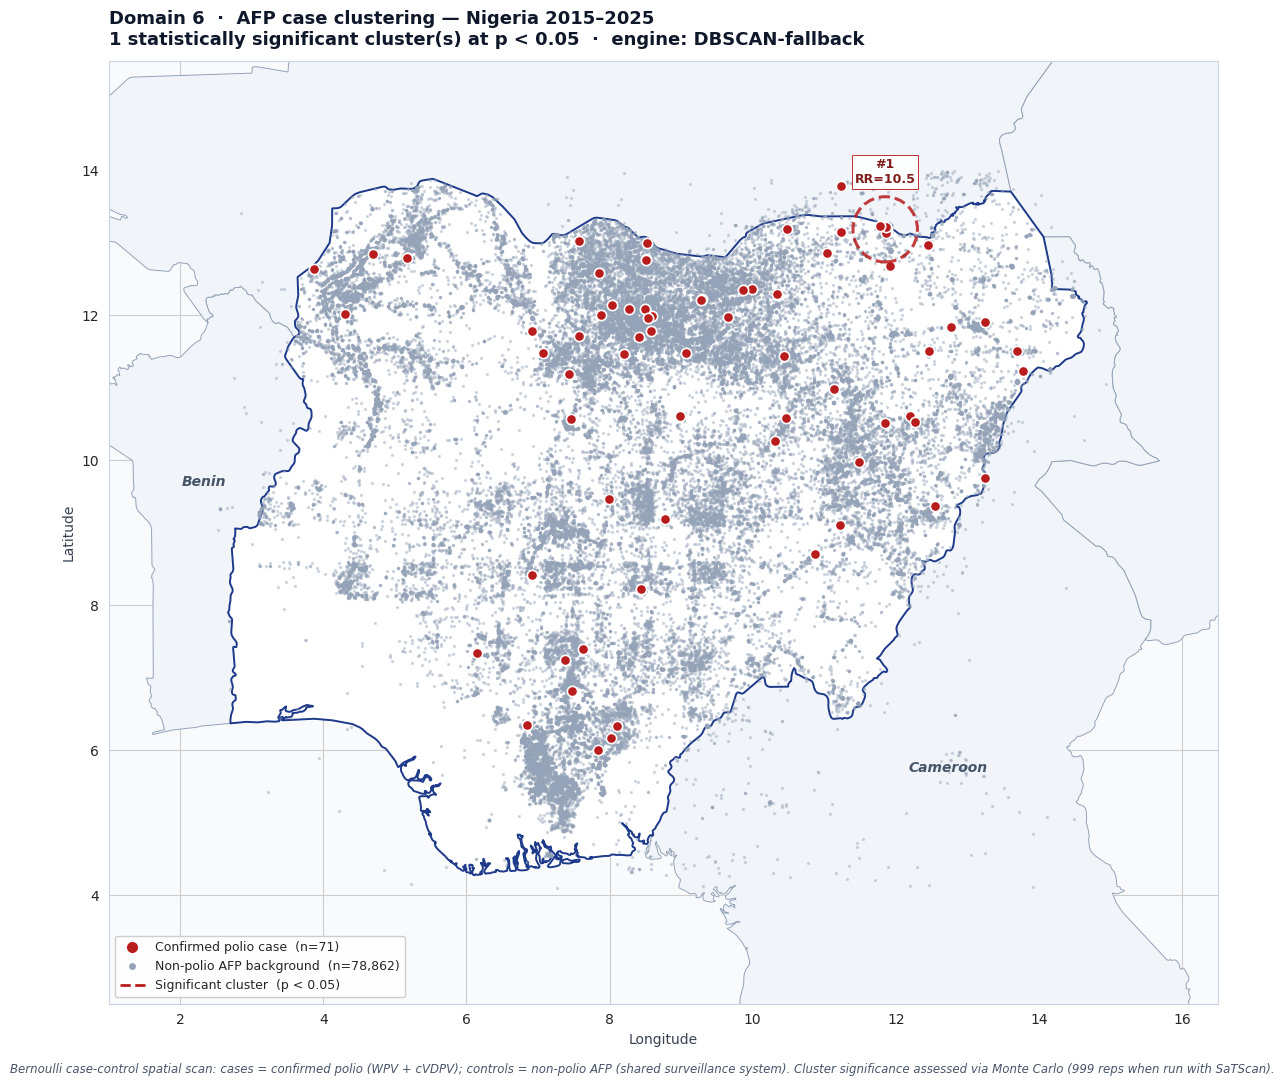


Saved: fig_d6_cluster_map.png


In [ ]:
# Cell 14 — Section 3.4: Render the cluster map
# Nigeria base map with admin-0 boundaries (loaded in the boundary cell),
# confirmed-polio cases as red dots, non-polio AFP as a faint blue density
# layer, and significant clusters as red circles sized by radius_km.

# --- Map ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 11), facecolor=BG)

# Neighbour countries — light grey wash
NG_REGION.plot(ax=ax, color="#F1F5F9", edgecolor="#94A3B8", lw=0.7, zorder=1)
# Nigeria — white fill, navy border
NG_ONLY.plot(ax=ax, color="#FFFFFF", edgecolor=PRIMARY, lw=1.4, zorder=2)

# Non-polio AFP as faint blue dots — the background density
non_polio = scan_df[scan_df["case_flag"] == 0]
ax.scatter(non_polio["lon"], non_polio["lat"], s=2, color="#94A3B8",
           alpha=0.35, zorder=3, label=f"Non-polio AFP (n={len(non_polio):,})")

# Confirmed polio cases as red filled dots
polio = scan_df[scan_df["case_flag"] == 1]
ax.scatter(polio["lon"], polio["lat"], s=55, color=ACCENT_RED,
           edgecolor="white", lw=1.2, zorder=5,
           label=f"Confirmed polio (n={len(polio)})")

# Cluster circles for significant clusters
if clusters_df is not None and len(clusters_df):
    sig = clusters_df[clusters_df["p_value"] < 0.05].copy()
    for _, c in sig.iterrows():
        # Convert radius from km to degrees (rough at this latitude)
        r_deg = c["radius_km"] / 111.0
        circle = plt.Circle((c["centroid_lon"], c["centroid_lat"]),
                             r_deg, fill=False, edgecolor=ACCENT_RED,
                             lw=2.2, ls="--", alpha=0.85, zorder=6)
        ax.add_patch(circle)
        # Cluster label
        ax.text(c["centroid_lon"], c["centroid_lat"] + r_deg + 0.15,
                f"#{int(c['cluster_id'])}\nRR={c['obs_exp_ratio']:.1f}",
                ha="center", va="bottom", fontsize=9, fontweight="bold",
                color="#7F1D1D",
                bbox=dict(facecolor="white", edgecolor=ACCENT_RED,
                           lw=0.7, pad=2, alpha=0.92),
                zorder=7)

# Border country labels
for _, row in NG_REGION[NG_REGION["NAME"] != "Nigeria"].iterrows():
    ax.annotate(row["NAME"],
                 xy=row.geometry.centroid.coords[0],
                 ha="center", fontsize=10, color="#475569",
                 style="italic", weight="bold", zorder=4)

# Bounds + cosmetics
ax.set_xlim(NG_LON_MIN - 1.5, NG_LON_MAX + 1.5)
ax.set_ylim(NG_LAT_MIN - 1.5, NG_LAT_MAX + 1.5)
ax.set_xlabel("Longitude", fontsize=10, color="#374151")
ax.set_ylabel("Latitude",  fontsize=10, color="#374151")
ax.set_facecolor("#F8FAFC")
for spine in ax.spines.values():
    spine.set_color("#CBD5E1")

# Title
sig_count = 0
if clusters_df is not None and len(clusters_df):
    sig_count = int((clusters_df["p_value"] < 0.05).sum())
ax.set_title(f"Domain 6  ·  AFP case clustering — Nigeria 2015–2025\n"
              f"{sig_count} statistically significant cluster(s) at p < 0.05  ·  "
              f"engine: {scan_engine}",
              fontsize=13, fontweight="bold", color="#0F172A", loc="left", pad=12)

# Legend
legend_handles = [
    plt.Line2D([0],[0], marker="o", color="w", markerfacecolor=ACCENT_RED,
                markeredgecolor="white", markersize=9,
                label=f"Confirmed polio case  (n={len(polio)})"),
    plt.Line2D([0],[0], marker="o", color="w", markerfacecolor="#94A3B8",
                markeredgecolor="none", markersize=5,
                label=f"Non-polio AFP background  (n={len(non_polio):,})"),
    plt.Line2D([0],[0], color=ACCENT_RED, lw=2, ls="--",
                label="Significant cluster  (p < 0.05)"),
]
ax.legend(handles=legend_handles, loc="lower left", fontsize=9,
          frameon=True, framealpha=0.95)

# Footer
fig.text(0.5, 0.02,
          "Bernoulli case-control spatial scan: cases = confirmed polio (WPV + cVDPV); "
          "controls = non-polio AFP (shared surveillance system). "
          "Cluster significance assessed via Monte Carlo (999 reps when run with SaTScan).",
          ha="center", fontsize=8.5, color="#475569", style="italic")

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig(OUTPUT_DIR / "fig_d6_cluster_map.png", dpi=150,
             bbox_inches="tight", facecolor=BG)
plt.show()
print(f"\nSaved: fig_d6_cluster_map.png")


---
## Section 4 — Campaign performance: vaccination history of AFP cases (Research Question I)

The OPV dose history of confirmed polio cases versus non-polio AFP controls is the cleanest available test of *reach failure* (children never received doses) versus *vaccine failure* (children received doses but the strain still circulates). The two interpretations call for very different programmatic responses, so this distinction matters operationally.


### 4.1 OPV-dose distribution and under-vaccination rate

Under-vaccination rate by case status:
                     n  under_vacc   pct
Non-polio AFP    77825        2303   3.0
Confirmed polio     91          15  16.5


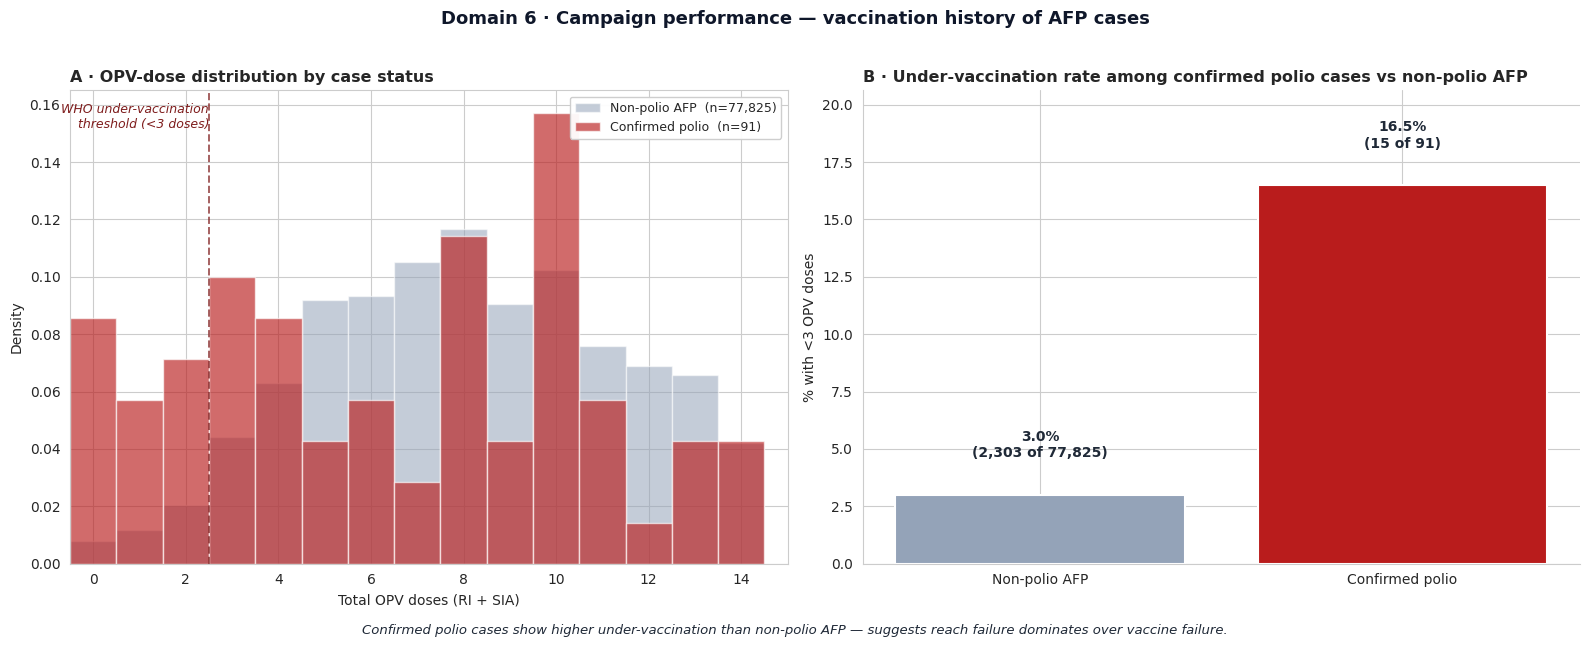


Saved: fig_d6_opv_history.png


In [ ]:
# Cell 16 — Section 4.1: OPV dose history of confirmed polio vs non-polio AFP
# The single most important programmatic distinction: are confirmed polio
# cases happening in children who never got vaccinated (reach failure) or in
# children who got their doses but the vaccine failed (vaccine efficacy)?
# A right-shifted distribution among polio-positives suggests vaccine failure;
# a left-shifted distribution suggests reach failure.

# Filter to records with OPV history recorded
opv_subset = afp[afp["opv_total"].notna() & (afp["opv_total"] >= 0)].copy()
opv_subset["polio_pos"] = (opv_subset["case_status"] != "Non-polio AFP")

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=BG)

# --- Panel A: Distribution histograms ---------------------------------------
ax = axes[0]
bins = np.arange(0, 16) - 0.5
nonpolio_opv = opv_subset.loc[~opv_subset["polio_pos"], "opv_total"]
polio_opv    = opv_subset.loc[ opv_subset["polio_pos"], "opv_total"]

ax.hist(nonpolio_opv, bins=bins, density=True, color="#94A3B8",
        alpha=0.55, edgecolor="white", lw=1, label=f"Non-polio AFP  (n={len(nonpolio_opv):,})")
ax.hist(polio_opv, bins=bins, density=True, color=ACCENT_RED,
        alpha=0.65, edgecolor="white", lw=1, label=f"Confirmed polio  (n={len(polio_opv)})")
# Under-vaccination cut line
ax.axvline(3 - 0.5, color="#7F1D1D", ls="--", lw=1.4, alpha=0.7)
ax.text(2.5, ax.get_ylim()[1] * 0.92, "WHO under-vaccination\nthreshold (<3 doses)",
        fontsize=9, color="#7F1D1D", ha="right", style="italic")
ax.set_xlim(-0.5, 15)
ax.set_xlabel("Total OPV doses (RI + SIA)", fontsize=10)
ax.set_ylabel("Density", fontsize=10)
ax.set_title("A · OPV-dose distribution by case status",
              fontsize=11.5, fontweight="bold", loc="left")
ax.legend(loc="upper right", fontsize=9, frameon=True, framealpha=0.95)

# --- Panel B: Under-vaccination rate by case status -------------------------
ax = axes[1]
uv_summary = opv_subset.groupby("polio_pos").agg(
    n=("opv_total", "size"),
    under_vacc=("opv_undervaxxed", "sum"),
).assign(pct=lambda x: (x["under_vacc"] / x["n"] * 100).round(1))
uv_summary.index = ["Non-polio AFP", "Confirmed polio"]
print("Under-vaccination rate by case status:")
print(uv_summary.to_string())

# Bar chart
colors = ["#94A3B8", ACCENT_RED]
bars = ax.bar(uv_summary.index, uv_summary["pct"],
               color=colors, edgecolor="white", lw=1.5)
for bar, pct, n_uv, n_total in zip(bars, uv_summary["pct"],
                                     uv_summary["under_vacc"], uv_summary["n"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f"{pct:.1f}%\n({int(n_uv):,} of {int(n_total):,})",
            ha="center", va="bottom", fontsize=10, fontweight="bold",
            color="#1F2937")

ax.set_ylabel("% with <3 OPV doses", fontsize=10)
ax.set_ylim(0, max(uv_summary["pct"]) * 1.25)
ax.set_title("B · Under-vaccination rate among confirmed polio cases vs non-polio AFP",
              fontsize=11.5, fontweight="bold", loc="left")
for spine in ["top","right"]: ax.spines[spine].set_visible(False)

# Interpretation footnote
share_uv_polio    = uv_summary.loc["Confirmed polio", "pct"]
share_uv_nonpolio = uv_summary.loc["Non-polio AFP", "pct"]
if share_uv_polio > share_uv_nonpolio + 5:
    interp = ("Confirmed polio cases show higher under-vaccination than non-polio "
              "AFP — suggests reach failure dominates over vaccine failure.")
elif share_uv_polio < share_uv_nonpolio - 5:
    interp = ("Confirmed polio cases show LOWER under-vaccination — most polio "
              "cases received doses, suggesting vaccine failure or strain "
              "circulation among vaccinated populations.")
else:
    interp = ("Under-vaccination rates are similar between confirmed polio and "
              "non-polio AFP — the polio signal is not strongly correlated "
              "with dose history in this dataset.")

fig.suptitle("Domain 6 · Campaign performance — vaccination history of AFP cases",
              fontsize=13, fontweight="bold", color="#0F172A", y=1.02)
fig.text(0.5, -0.02, interp, ha="center", fontsize=9.5,
          color="#1F2937", style="italic", wrap=True)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_d6_opv_history.png", dpi=150,
             bbox_inches="tight", facecolor=BG)
plt.show()
print(f"\nSaved: fig_d6_opv_history.png")


### 4.2 Under-vaccination heatmap by state and year

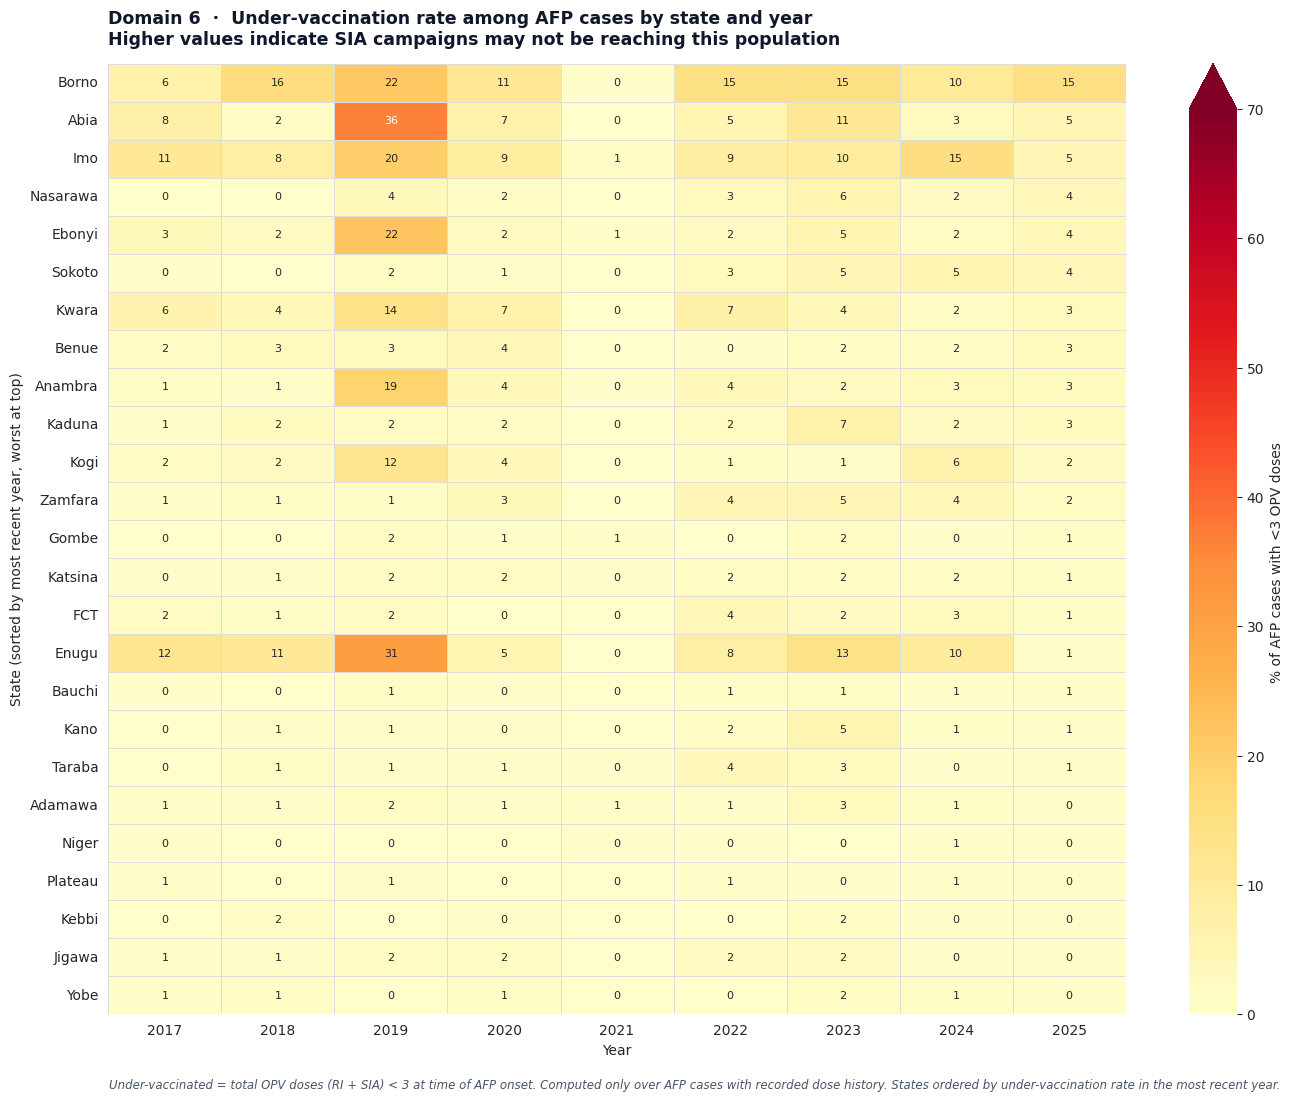


Saved: fig_d6_undervacc_heatmap.png
States × years analysed: (25, 9)


In [ ]:
# Cell 18 — Section 4.2: Under-vaccination heatmap by state × year
# Where (state) and when (year) are the AFP cases under-vaccinated? The %
# of AFP cases with <3 OPV doses is a proxy for SIA campaign reach failure.

uv_pivot = (afp[afp["opv_total"].notna()]
              .groupby(["state", "year"])
              .agg(n=("opv_total", "size"),
                   uv=("opv_undervaxxed", "sum"))
              .assign(pct=lambda x: (x["uv"] / x["n"] * 100).round(1))
              .reset_index()
              .pivot(index="state", columns="year", values="pct"))

# Keep only years with reasonable sample sizes (drop sparsely-reported years)
yr_totals = afp.groupby("year").size()
keep_yrs  = yr_totals[yr_totals > 1000].index.tolist()
uv_pivot  = uv_pivot[[y for y in keep_yrs if y in uv_pivot.columns]]

# Sort states by 2024 under-vaccination rate (worst at top)
sort_year = max(keep_yrs)
uv_pivot  = uv_pivot.reindex(uv_pivot[sort_year].sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(14, 11), facecolor=BG)
sns.heatmap(uv_pivot, ax=ax, cmap="YlOrRd", vmin=0, vmax=70,
             linewidths=0.4, linecolor="#ddd",
             cbar_kws={"label": "% of AFP cases with <3 OPV doses",
                        "extend": "max"},
             annot=True, fmt=".0f", annot_kws={"size": 8})

ax.set_title("Domain 6  ·  Under-vaccination rate among AFP cases by state and year\n"
              "Higher values indicate SIA campaigns may not be reaching this population",
              fontsize=12.5, fontweight="bold", color="#0F172A",
              loc="left", pad=14)
ax.set_xlabel("Year", fontsize=10)
ax.set_ylabel("State (sorted by most recent year, worst at top)", fontsize=10)

fig.text(0.5, 0.005,
          "Under-vaccinated = total OPV doses (RI + SIA) < 3 at time of AFP onset. "
          "Computed only over AFP cases with recorded dose history. "
          "States ordered by under-vaccination rate in the most recent year.",
          ha="center", fontsize=8.5, color="#475569", style="italic")

plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.savefig(OUTPUT_DIR / "fig_d6_undervacc_heatmap.png", dpi=150,
             bbox_inches="tight", facecolor=BG)
plt.show()
print(f"\nSaved: fig_d6_undervacc_heatmap.png")
print(f"States × years analysed: {uv_pivot.shape}")


---
## Section 5 — International border proximity (Research Question I)

For each geo-valid AFP case, the great-circle distance to the nearest point on Nigeria's international land border with Benin, Niger, Chad, or Cameroon is computed in metric coordinates (EPSG:32632) against the Natural Earth 1:10m boundary layer. Cases are stratified into <25 km, 25–100 km, and ≥100 km bands, and the confirmed-polio rate per 1,000 AFP is compared across bands.

Eight key border crossings monitored by IOM Displacement Tracking Matrix are annotated on the map for operational context — these are not analytical inputs but help reviewers connect statistical findings to the operational corridors NPHCDA already monitors.


### 5.1 Distance-to-border computation

In [ ]:
# Cell 20 — Section 5: International border proximity
# For each geo-valid AFP case, compute great-circle distance to the nearest
# point on Nigeria's international land border. Stratify into <25km,
# 25–100km, ≥100km. Compare confirmed-polio rate across the three strata —
# does proximity to the border elevate polio risk?

from shapely.ops import unary_union
from shapely.geometry import LineString, MultiLineString, MultiPolygon
import pyproj

# --- Build Nigeria's international border (excluding coast) -----------------
ng_geom = NG_ONLY.geometry.iloc[0]
if isinstance(ng_geom, MultiPolygon):
    ng_geom = max(ng_geom.geoms, key=lambda p: p.area)
ng_boundary = ng_geom.boundary    # full perimeter (incl. coast)

# Coastline is the southern edge. We want the land border with Niger, Chad,
# Cameroon, Benin. Subtract a buffered coast from the boundary by intersecting
# the boundary with the union of neighbour countries (excluding sea).
neighbour_geom = unary_union(NG_REGION[NG_REGION["NAME"] != "Nigeria"].geometry)
land_border = ng_boundary.intersection(neighbour_geom.buffer(0.01))
# The intersection may return GeometryCollection — coerce to lines only
def to_linestrings(geom):
    if hasattr(geom, "geoms"):
        for g in geom.geoms:
            yield from to_linestrings(g)
    elif isinstance(geom, (LineString, MultiLineString)):
        if isinstance(geom, LineString):
            yield geom
        else:
            yield from geom.geoms
land_lines = list(to_linestrings(land_border))
print(f"Land-border segments: {len(land_lines)}")

# --- Project to a metric CRS for accurate distance calculation --------------
# UTM zone 32N covers most of Nigeria; EPSG:32632
proj_to_m   = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:32632",
                                           always_xy=True).transform
proj_to_deg = pyproj.Transformer.from_crs("EPSG:32632", "EPSG:4326",
                                           always_xy=True).transform

from shapely.ops import transform as shapely_transform
land_lines_m = [shapely_transform(proj_to_m, ln) for ln in land_lines]
border_union_m = unary_union(land_lines_m)

# --- Compute distance from each geo-valid AFP case to the border ------------
border_cases = afp[afp["geo_valid"]].copy()
def dist_to_border_km(lon, lat):
    px, py = proj_to_m(lon, lat)
    return border_union_m.distance(Point(px, py)) / 1000.0

# Vectorise via apply (50k+ points; ~10s)
print("Computing case-to-border distances (~10s for 79k cases) ...")
border_cases["border_km"] = [dist_to_border_km(lo, la)
                              for lo, la in zip(border_cases["lon"],
                                                  border_cases["lat"])]

# Stratify
def stratum(km):
    if km < 25:  return "<25 km"
    if km < 100: return "25–100 km"
    return "≥100 km"
border_cases["border_band"] = border_cases["border_km"].apply(stratum)

# --- Summary ----------------------------------------------------------------
summary = (border_cases.groupby("border_band")
             .agg(total_afp=("case_status", "size"),
                  confirmed_polio=("case_status",
                                    lambda s: (s != "Non-polio AFP").sum()))
             .assign(rate_per_1000=lambda x:
                      (x["confirmed_polio"] / x["total_afp"] * 1000).round(2)))
# Force band ordering
summary = summary.reindex(["<25 km", "25–100 km", "≥100 km"])
print("\nConfirmed-polio rate by border-proximity band:")
print(summary.to_string())


Land-border segments: 2
Computing case-to-border distances (~10s for 79k cases) ...

Confirmed-polio rate by border-proximity band:
             total_afp  confirmed_polio  rate_per_1000
border_band                                           
<25 km            5992               15           2.50
25–100 km        21691               17           0.78
≥100 km          51250               39           0.76


### 5.2 Border-proximity map and stratified detection rate

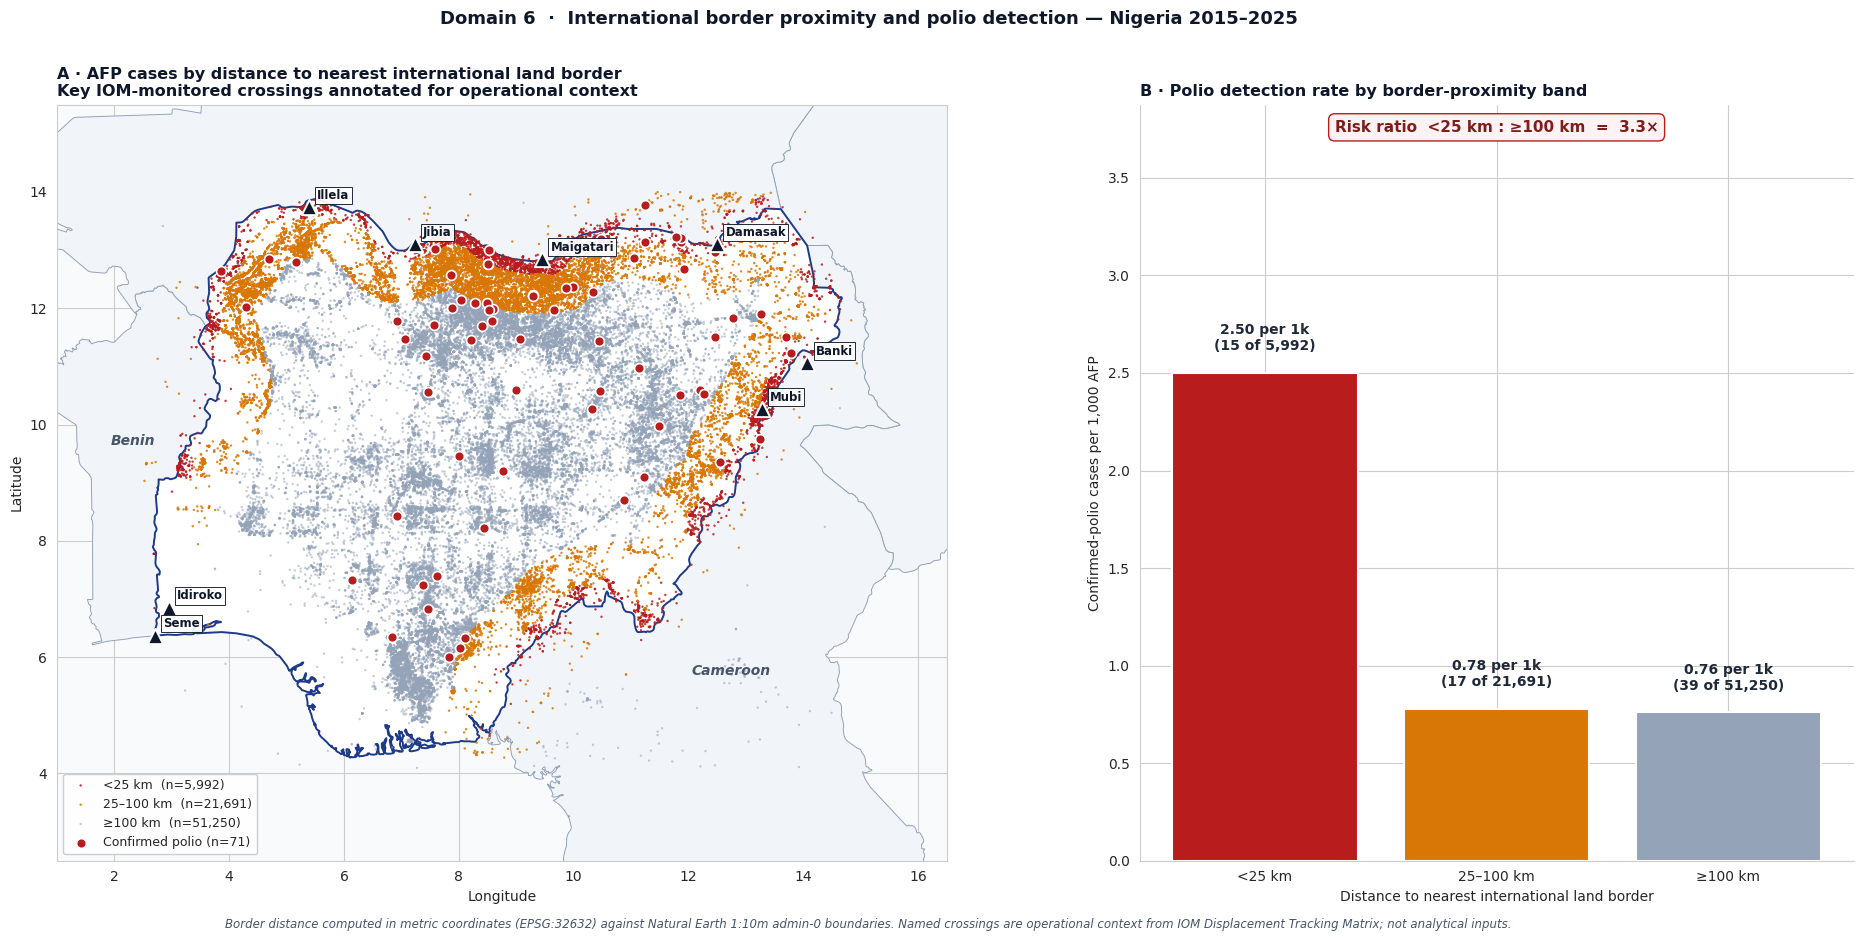


Saved: fig_d6_border_proximity.png


In [ ]:
# Cell 22 — Section 5.2: Visualise border proximity
# Two-panel figure:
#   Left  — Map of AFP cases coloured by border-distance band, with named
#           crossings annotated for operational context
#   Right — Bar chart of confirmed-polio rate per 1,000 AFP by band

# Hand-coded key border crossings from IOM DTM operational corridors.
# Coordinates approximate; included as annotation context, not as data inputs.
NAMED_CROSSINGS = [
    ("Illela",      "Sokoto-Niger",   13.74,  5.39),
    ("Jibia",       "Katsina-Niger", 13.10,  7.23),
    ("Maigatari",   "Jigawa-Niger",  12.85,  9.45),
    ("Damasak",     "Borno-Niger",   13.10, 12.50),
    ("Banki",       "Borno-Cameroon",11.06, 14.07),
    ("Mubi",        "Adamawa-Cam.",   10.27, 13.27),
    ("Idiroko",     "Ogun-Benin",     6.85,  2.95),
    ("Seme",        "Lagos-Benin",    6.37,  2.71),
]

fig, axes = plt.subplots(1, 2, figsize=(20, 9), facecolor=BG,
                          gridspec_kw={"width_ratios": [1.7, 1]})

# --- Panel A: Map -----------------------------------------------------------
ax = axes[0]
NG_REGION.plot(ax=ax, color="#F1F5F9", edgecolor="#94A3B8", lw=0.7, zorder=1)
NG_ONLY.plot(ax=ax, color="#FFFFFF", edgecolor=PRIMARY, lw=1.4, zorder=2)

band_colors = {"<25 km": ACCENT_RED, "25–100 km": ACCENT_AMB, "≥100 km": "#94A3B8"}
for band, color in band_colors.items():
    sub = border_cases[border_cases["border_band"] == band]
    ax.scatter(sub["lon"], sub["lat"], s=3, color=color,
               alpha=0.55 if band == "≥100 km" else 0.85,
               edgecolor="none", zorder=3,
               label=f"{band}  (n={len(sub):,})")

# Confirmed polio cases on top
polio = border_cases[border_cases["case_status"] != "Non-polio AFP"]
ax.scatter(polio["lon"], polio["lat"], s=50, color=ACCENT_RED,
           edgecolor="white", lw=1.2, zorder=5,
           label=f"Confirmed polio (n={len(polio)})")

# Named crossings
for name, route, lat, lon in NAMED_CROSSINGS:
    ax.scatter([lon], [lat], s=120, marker="^", color="#0F172A",
               edgecolor="white", lw=1.4, zorder=6)
    ax.annotate(name, xy=(lon, lat), xytext=(6, 6),
                 textcoords="offset points", fontsize=8.5,
                 fontweight="bold", color="#0F172A", zorder=7,
                 bbox=dict(facecolor="white", edgecolor="#0F172A",
                            lw=0.7, pad=1.5, alpha=0.92))

for _, row in NG_REGION[NG_REGION["NAME"] != "Nigeria"].iterrows():
    ax.annotate(row["NAME"], xy=row.geometry.centroid.coords[0],
                 ha="center", fontsize=10, color="#475569",
                 style="italic", weight="bold", zorder=4)

ax.set_xlim(NG_LON_MIN - 1.5, NG_LON_MAX + 1.5)
ax.set_ylim(NG_LAT_MIN - 1.5, NG_LAT_MAX + 1.5)
ax.set_xlabel("Longitude", fontsize=10)
ax.set_ylabel("Latitude", fontsize=10)
ax.set_facecolor("#F8FAFC")
ax.set_title("A · AFP cases by distance to nearest international land border\n"
              "Key IOM-monitored crossings annotated for operational context",
              fontsize=11.5, fontweight="bold", loc="left", color="#0F172A")
ax.legend(loc="lower left", fontsize=9, frameon=True, framealpha=0.95)

# --- Panel B: Confirmed-polio rate by band -----------------------------------
ax = axes[1]
bands_order = ["<25 km", "25–100 km", "≥100 km"]
rates = summary.reindex(bands_order)["rate_per_1000"]
counts = summary.reindex(bands_order)["confirmed_polio"]
totals = summary.reindex(bands_order)["total_afp"]
colors = [band_colors[b] for b in bands_order]

bars = ax.bar(bands_order, rates.values, color=colors,
              edgecolor="white", lw=1.5)
for b, r, c, t in zip(bars, rates.values, counts.values, totals.values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.1,
            f"{r:.2f} per 1k\n({int(c)} of {int(t):,})",
            ha="center", va="bottom", fontsize=10, fontweight="bold",
            color="#1F2937")

ax.set_ylabel("Confirmed-polio cases per 1,000 AFP", fontsize=10)
ax.set_xlabel("Distance to nearest international land border", fontsize=10)
ax.set_title("B · Polio detection rate by border-proximity band",
              fontsize=11.5, fontweight="bold", loc="left", color="#0F172A")
ax.set_ylim(0, max(rates.values) * 1.35 + 0.5)
for spine in ["top", "right"]: ax.spines[spine].set_visible(False)

# Risk-ratio annotation
rr = rates["<25 km"] / max(rates["≥100 km"], 0.001)
ax.text(0.5, 0.98, f"Risk ratio  <25 km : ≥100 km  =  {rr:.1f}×",
        transform=ax.transAxes, ha="center", va="top",
        fontsize=11, fontweight="bold", color="#7F1D1D",
        bbox=dict(facecolor="#FEF2F2", edgecolor=ACCENT_RED,
                   lw=1, pad=6, boxstyle="round,pad=0.4"))

fig.suptitle("Domain 6  ·  International border proximity and polio detection — "
              "Nigeria 2015–2025",
              fontsize=13, fontweight="bold", color="#0F172A", y=1.01)

fig.text(0.5, -0.01,
          "Border distance computed in metric coordinates (EPSG:32632) against "
          "Natural Earth 1:10m admin-0 boundaries. Named crossings are operational "
          "context from IOM Displacement Tracking Matrix; not analytical inputs.",
          ha="center", fontsize=8.5, color="#475569", style="italic")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_d6_border_proximity.png", dpi=150,
             bbox_inches="tight", facecolor=BG)
plt.show()
print(f"\nSaved: fig_d6_border_proximity.png")


---
## Section 6 — Detection-trend forecast and interruption pathway (Research Question II)

Two complementary forecasting approaches are run side-by-side to answer the second research question.

**Model A — Negative-binomial GLM on annual cVDPV counts.** Count data with overdispersion is the textbook use case for NB-GLM, and cVDPV is the residual epidemiology in Nigeria (wild polio has been at zero since 2017). The NB-GLM estimates the underlying rate and its uncertainty in count units, with confidence intervals on the original scale.

**Model B — Prophet on monthly confirmed-polio counts.** Prophet is the consortium's standard time-series forecaster (Domain 1 and Domain 2). Running Prophet here as well lets reviewers compare a count-appropriate model (NB-GLM) against the consortium's general-purpose engine.

**Interruption year.** Defined operationally as the first forecast year in which the upper 95% confidence interval falls below 1 case — the year by which we can confidently rule out further detections.


### 6.1 Fit NB-GLM and Prophet, compute interruption-year estimates

In [ ]:
# Cell 24 — Section 6: Detection trend forecast & interruption pathway
# Two models run side-by-side on annual confirmed-polio counts:
#   • Negative-binomial GLM (count-data appropriate)
#   • Prophet (consortium's standard time-series forecaster)
# Both extrapolate to 2030. The "interruption year" is the first year the
# 95% upper CI is < 1, i.e. when we can rule out further detections.

import statsmodels.api as sm
from prophet import Prophet
import logging
logging.getLogger("prophet").setLevel(logging.WARNING)
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)

confirmed = afp[afp["case_status"] != "Non-polio AFP"].copy()
annual = (confirmed.groupby(["year", "case_status"])
            .size().unstack(fill_value=0).reset_index())
# Ensure both columns exist
for c in ["WPV", "cVDPV"]:
    if c not in annual.columns: annual[c] = 0
annual["all_confirmed"] = annual["WPV"] + annual["cVDPV"]
annual = annual.sort_values("year").reset_index(drop=True)
print("Annual confirmed-polio counts:")
print(annual.to_string(index=False))

last_year = int(annual["year"].max())
fc_years  = list(range(last_year + 1, 2031))

# === Model A: Negative-binomial GLM on cVDPV (the residual epidemiology) ====
y = annual["cVDPV"].values
x = annual["year"].values - annual["year"].min()
X = sm.add_constant(x)
try:
    nb_model = sm.GLM(y, X, family=sm.families.NegativeBinomial(alpha=1.0)).fit()
    fc_x_nb = (np.array(fc_years) - annual["year"].min())
    fc_X_nb = sm.add_constant(fc_x_nb, has_constant="add")
    nb_pred = nb_model.get_prediction(fc_X_nb)
    nb_mean = nb_pred.predicted_mean
    nb_ci   = nb_pred.conf_int(alpha=0.05)
    nb_summary = pd.DataFrame({
        "year": fc_years,
        "predicted": nb_mean.round(2),
        "lo95": nb_ci[:, 0].round(2),
        "hi95": nb_ci[:, 1].round(2),
    })
    print("\nNegative-binomial GLM cVDPV forecast:")
    print(nb_summary.to_string(index=False))
except Exception as e:
    nb_summary = None
    print(f"NB-GLM failed: {e}")

# === Model B: Prophet on monthly confirmed-polio counts ====================
monthly = (confirmed.groupby(confirmed["DateOfOnset"].dt.to_period("M"))
             .size().reset_index(name="y"))
monthly["ds"] = monthly["DateOfOnset"].dt.to_timestamp()
monthly = monthly[["ds", "y"]].sort_values("ds")
# Pad missing months with zero so Prophet sees the full timeline
full = pd.date_range(monthly["ds"].min(), monthly["ds"].max(), freq="MS")
monthly = monthly.set_index("ds").reindex(full, fill_value=0).rename_axis("ds").reset_index()

# Floor at 0 — counts can't go negative
m = Prophet(yearly_seasonality=False, weekly_seasonality=False,
            daily_seasonality=False, interval_width=0.95,
            changepoint_prior_scale=0.05, growth="linear")
m.fit(monthly)
months_to_2030 = ((2030 - last_year) * 12) + (12 - monthly["ds"].dt.month.iloc[-1])
future = m.make_future_dataframe(periods=months_to_2030, freq="MS")
prophet_fc = m.predict(future)
# Aggregate monthly forecast to annual
prophet_annual = (prophet_fc.assign(year=prophet_fc["ds"].dt.year)
                              .groupby("year")
                              .agg(predicted=("yhat", "sum"),
                                   lo95=("yhat_lower", "sum"),
                                   hi95=("yhat_upper", "sum"))
                              .reset_index())
prophet_annual[["predicted", "lo95", "hi95"]] = prophet_annual[
    ["predicted", "lo95", "hi95"]].clip(lower=0).round(2)
prophet_fc_only = prophet_annual[prophet_annual["year"].isin(fc_years)]
print("\nProphet annual aggregate forecast (confirmed polio):")
print(prophet_fc_only.to_string(index=False))

# === Interruption-year estimation ============================================
def interruption_year(df_fc):
    """First future year for which upper-95% CI is below 1."""
    below = df_fc[df_fc["hi95"] < 1]
    return int(below["year"].iloc[0]) if len(below) else None

ir_nb      = interruption_year(nb_summary) if nb_summary is not None else None
ir_prophet = interruption_year(prophet_fc_only)
print()
print(f"Estimated interruption year (upper-95% CI crosses below 1):")
print(f"  NB-GLM (cVDPV):       {ir_nb}")
print(f"  Prophet (all confirmed): {ir_prophet}")


Annual confirmed-polio counts:
 year  WPV  cVDPV  all_confirmed
 2015    0     22             22
 2016    4     25             29
 2017    0     10             10
 2018    0     44             44
 2019    0     10             10
 2020    0     10             10
 2021    0      6              6
 2022    0      5              5
 2023    0      3              3
 2024    0      5              5

Negative-binomial GLM cVDPV forecast:
 year  predicted  lo95  hi95
 2025       2.99  0.70 12.80
 2026       2.35  0.45 12.35
 2027       1.84  0.28 11.98
 2028       1.44  0.18 11.66
 2029       1.13  0.11 11.37
 2030       0.89  0.07 11.11

Prophet annual aggregate forecast (confirmed polio):
 year  predicted  lo95  hi95
 2025        0.3   0.0 37.81
 2026        0.0   0.0 36.57
 2027        0.0   0.0 33.81
 2028        0.0   0.0 30.84
 2029        0.0   0.0 28.33
 2030        0.0   0.0 25.82

Estimated interruption year (upper-95% CI crosses below 1):
  NB-GLM (cVDPV):       None
  Prophet (all co

### 6.2 Interruption pathway visualisation

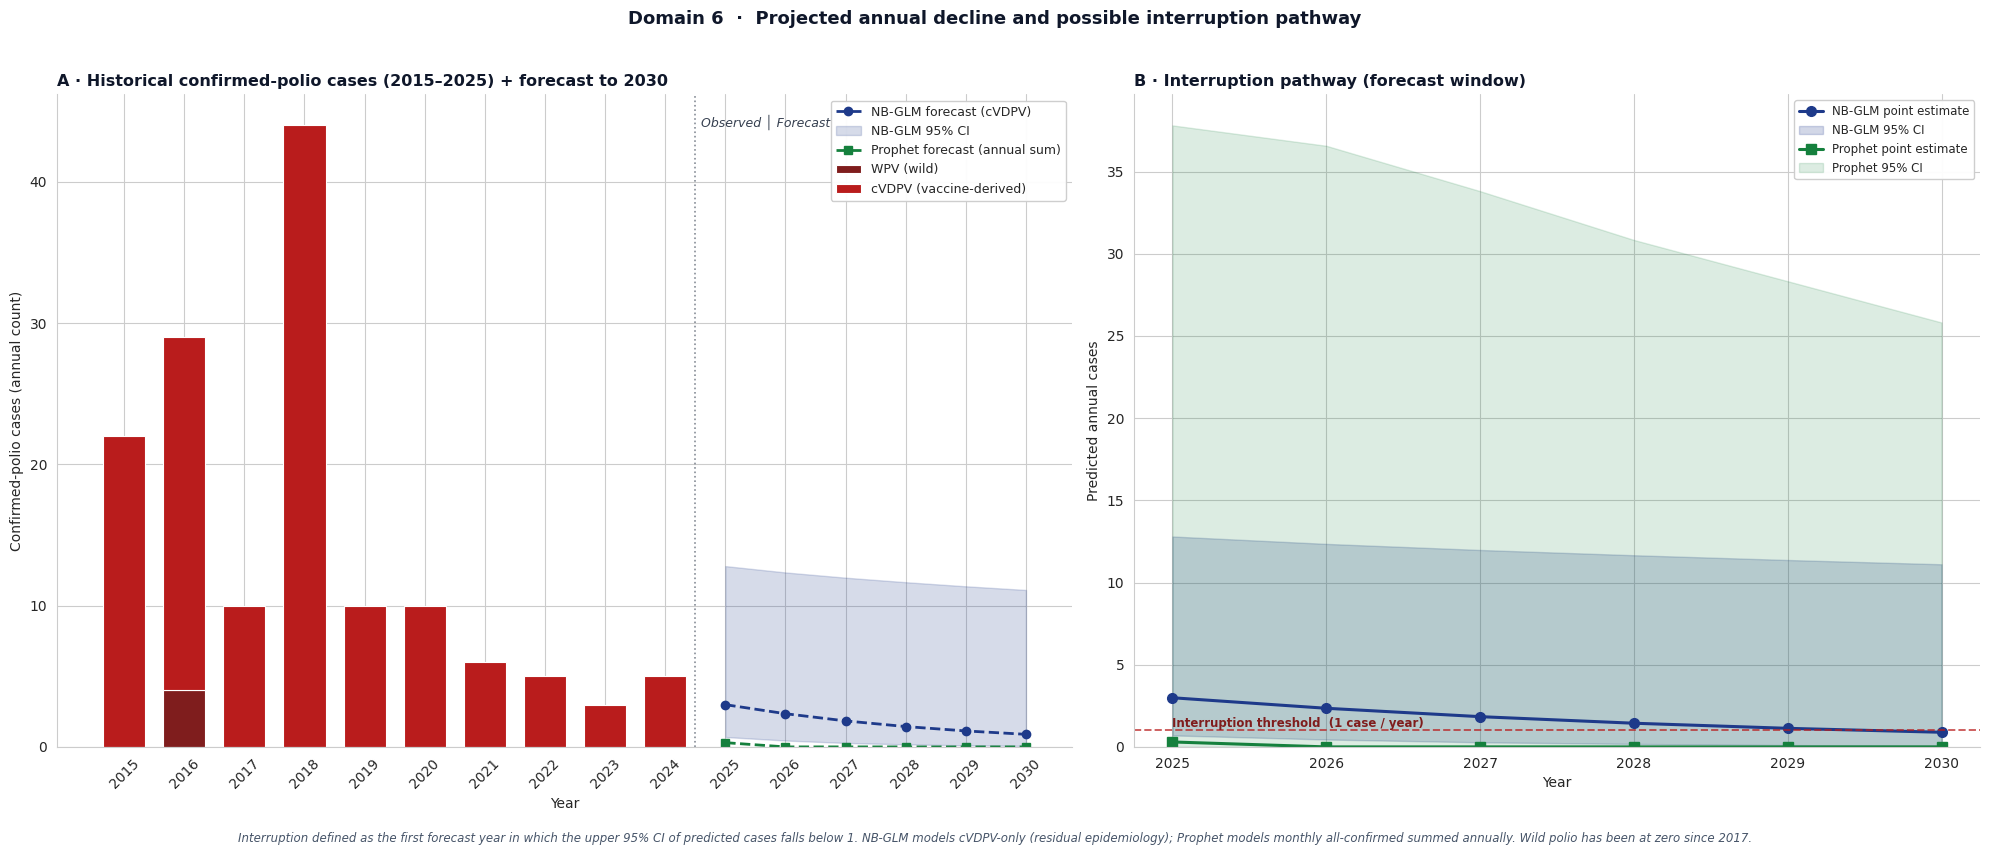


Saved: fig_d6_interruption_pathway.png


In [ ]:
# Cell 26 — Section 6.2: Interruption pathway visualisation
# Two-panel figure:
#   Left  — Annual confirmed cases (historical) + both model forecasts
#   Right — Closer view of forecast with 95% CI bands and interruption-year marker

fig, axes = plt.subplots(1, 2, figsize=(20, 8), facecolor=BG,
                          gridspec_kw={"width_ratios": [1.2, 1]})

# --- Panel A: Historical + forecast --------------------------------------
ax = axes[0]
years_hist = annual["year"].values
ax.bar(years_hist, annual["WPV"].values, color="#7F1D1D",
        edgecolor="white", lw=0.8, width=0.7, label="WPV (wild)")
ax.bar(years_hist, annual["cVDPV"].values, bottom=annual["WPV"].values,
        color=ACCENT_RED, edgecolor="white", lw=0.8, width=0.7,
        label="cVDPV (vaccine-derived)")

# Overlay NB-GLM forecast for cVDPV
if nb_summary is not None:
    ax.plot(nb_summary["year"], nb_summary["predicted"],
            "--o", color=PRIMARY, lw=2, markersize=6,
            label="NB-GLM forecast (cVDPV)")
    ax.fill_between(nb_summary["year"], nb_summary["lo95"], nb_summary["hi95"],
                    color=PRIMARY, alpha=0.18, label="NB-GLM 95% CI")

# Overlay Prophet forecast (annual aggregate)
ax.plot(prophet_fc_only["year"], prophet_fc_only["predicted"],
        "--s", color="#15803D", lw=2, markersize=6,
        label="Prophet forecast (annual sum)")

ax.axvline(last_year + 0.5, color="#374151", lw=1.2, alpha=0.6, ls=":")
ax.text(last_year + 0.6, ax.get_ylim()[1] * 0.95,
        "Observed │ Forecast", fontsize=9, color="#374151", style="italic")

ax.set_xlabel("Year", fontsize=10)
ax.set_ylabel("Confirmed-polio cases (annual count)", fontsize=10)
ax.set_title("A · Historical confirmed-polio cases (2015–2025) + forecast to 2030",
              fontsize=11.5, fontweight="bold", loc="left", color="#0F172A")
ax.legend(loc="upper right", fontsize=9, frameon=True, framealpha=0.95)
ax.set_xticks(list(years_hist) + fc_years)
ax.tick_params(axis="x", rotation=45)
for spine in ["top", "right"]: ax.spines[spine].set_visible(False)

# --- Panel B: Forecast-only with interruption-year marker ---------------
ax = axes[1]
if nb_summary is not None:
    ax.plot(nb_summary["year"], nb_summary["predicted"],
            "-o", color=PRIMARY, lw=2.2, markersize=7,
            label="NB-GLM point estimate")
    ax.fill_between(nb_summary["year"], nb_summary["lo95"], nb_summary["hi95"],
                    color=PRIMARY, alpha=0.20, label="NB-GLM 95% CI")
ax.plot(prophet_fc_only["year"], prophet_fc_only["predicted"],
        "-s", color="#15803D", lw=2.2, markersize=7,
        label="Prophet point estimate")
ax.fill_between(prophet_fc_only["year"], prophet_fc_only["lo95"],
                 prophet_fc_only["hi95"], color="#15803D", alpha=0.15,
                 label="Prophet 95% CI")

# Interruption threshold
ax.axhline(1.0, color=ACCENT_RED, lw=1.4, ls="--", alpha=0.7)
ax.text(fc_years[0], 1.05, "Interruption threshold  (1 case / year)",
        fontsize=8.5, color="#7F1D1D", fontweight="bold", va="bottom")

# Mark interruption years
if ir_nb:
    ax.axvline(ir_nb, color=PRIMARY, lw=1.5, ls=":", alpha=0.85)
    ax.text(ir_nb, ax.get_ylim()[1] * 0.85, f"NB-GLM\ninterruption\n{ir_nb}",
            fontsize=9, color=PRIMARY, ha="center", fontweight="bold",
            bbox=dict(facecolor="white", edgecolor=PRIMARY, lw=0.7,
                       pad=3, alpha=0.92))
if ir_prophet:
    ax.axvline(ir_prophet, color="#15803D", lw=1.5, ls=":", alpha=0.85)
    ax.text(ir_prophet, ax.get_ylim()[1] * 0.65,
            f"Prophet\ninterruption\n{ir_prophet}",
            fontsize=9, color="#15803D", ha="center", fontweight="bold",
            bbox=dict(facecolor="white", edgecolor="#15803D", lw=0.7,
                       pad=3, alpha=0.92))

ax.set_xlabel("Year", fontsize=10)
ax.set_ylabel("Predicted annual cases", fontsize=10)
ax.set_title("B · Interruption pathway (forecast window)",
              fontsize=11.5, fontweight="bold", loc="left", color="#0F172A")
ax.legend(loc="upper right", fontsize=8.5, frameon=True, framealpha=0.95)
ax.set_ylim(bottom=0)
for spine in ["top", "right"]: ax.spines[spine].set_visible(False)

fig.suptitle("Domain 6  ·  Projected annual decline and possible interruption pathway",
              fontsize=13, fontweight="bold", color="#0F172A", y=1.02)
fig.text(0.5, -0.02,
          "Interruption defined as the first forecast year in which the upper "
          "95% CI of predicted cases falls below 1. NB-GLM models cVDPV-only "
          "(residual epidemiology); Prophet models monthly all-confirmed "
          "summed annually. Wild polio has been at zero since 2017.",
          ha="center", fontsize=8.5, color="#475569", style="italic")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_d6_interruption_pathway.png", dpi=150,
             bbox_inches="tight", facecolor=BG)
plt.show()
print(f"\nSaved: fig_d6_interruption_pathway.png")


### 6.3 Recurrence-free survival — formal interruption-pathway analysis

The interruption question reframed in survival-analysis terms: *given the last confirmed detection in a state, what is the probability that more than 36 months pass before the next one?* The 36-month threshold matches the WHO criterion for polio-free certification.

For each state, inter-arrival times between consecutive confirmed polio cases are computed, with the interval since the last case right-censored at the dataset cutoff (31 December 2025). A non-parametric Kaplan-Meier estimator and a parametric exponential model are fitted to these durations; the exponential model yields a national hazard rate that translates directly into "expected confirmed cases per state-year".

This is a more statistically defensible answer to Research Question II than the NB-GLM count-forecast: it respects right-censoring explicitly and produces certification-readiness probabilities per state, which is the operational quantity NPHCDA and WHO need.

In [ ]:
# Cell 28 — Section 6.3: Recurrence-free survival (inter-arrival of confirmed
# polio cases at the state level)
#
# The interruption-pathway question reframed in survival-analysis terms:
# *given the last confirmed detection in a state, what is the probability that
# more than 36 months will pass before the next one?* The 36-month threshold
# matches the WHO criterion for polio-free certification (three consecutive
# years without detection).
#
# Method:
#   • For each state, compute inter-arrival times between consecutive
#     confirmed polio cases. The interval after the last case is right-
#     censored at the dataset cutoff (31 Dec 2025).
#   • Fit a non-parametric Kaplan-Meier estimator on inter-arrival times.
#   • Fit a parametric exponential model to extract the hazard rate
#     (cases per state-year) and project the certification-readiness
#     probability per state.

%pip install -qqq lifelines
from lifelines import KaplanMeierFitter, ExponentialFitter
from lifelines.utils import median_survival_times

CUTOFF = pd.Timestamp("2025-12-31")
CERT_WINDOW_DAYS = 365 * 3   # WHO 3-year certification window

confirmed = afp[afp["case_status"] != "Non-polio AFP"][
    ["state", "DateOfOnset", "case_status"]].dropna()
confirmed = confirmed.sort_values(["state", "DateOfOnset"]).reset_index(drop=True)

# Build inter-arrival records: one row per *interval* in each state, plus a
# final right-censored row representing "time since last case to dataset
# cutoff" for each state that ever had a confirmed case.
records = []
for state, grp in confirmed.groupby("state"):
    dates = grp["DateOfOnset"].sort_values().tolist()
    # Inter-arrival intervals (event = 1, next case observed)
    for i in range(1, len(dates)):
        delta = (dates[i] - dates[i-1]).days
        if delta >= 0:
            records.append({"state": state, "days": delta, "event": 1,
                             "interval_type": "case-to-case"})
    # Right-censored "time since last case" (event = 0)
    last = dates[-1]
    days_since = (CUTOFF - last).days
    if days_since > 0:
        records.append({"state": state, "days": days_since, "event": 0,
                         "interval_type": "last-to-cutoff (censored)"})

surv_df = pd.DataFrame(records)
print(f"Survival input: {len(surv_df)} intervals across {surv_df['state'].nunique()} states")
print(f"  Events (case-to-case): {(surv_df['event']==1).sum()}")
print(f"  Right-censored:        {(surv_df['event']==0).sum()}")

# === Overall Kaplan-Meier on inter-arrival times ============================
kmf = KaplanMeierFitter()
kmf.fit(surv_df["days"], surv_df["event"], label="All confirmed cases")

median_iat = kmf.median_survival_time_
print(f"\nMedian inter-arrival time: "
      f"{'undefined (>50% censored)' if pd.isna(median_iat) else f'{median_iat:.0f} days'}")

# === Parametric exponential model -- recovers a hazard rate that translates
#     directly into 'expected cases per state-year' ===========================
# The exponential fitter requires strictly positive durations. Two
# confirmed polio cases in the same state on the same day produce
# zero-day inter-arrivals (rare, but observed); floor those at 0.5 day
# so the fit doesn't refuse the input.
surv_df_fit = surv_df.copy()
surv_df_fit["days"] = surv_df_fit["days"].clip(lower=0.5)
ef = ExponentialFitter()
ef.fit(surv_df_fit["days"], surv_df_fit["event"], label="Exponential")
lambda_per_day = 1 / ef.lambda_
lambda_per_year = lambda_per_day * 365
print(f"Exponential hazard: {lambda_per_year:.4f} cases per state-year "
      f"(λ = 1/{ef.lambda_:.1f} days)")

# Probability of NO new detection in a given window
def survival_prob(days):
    return float(ef.predict(days))

print(f"\nProbability that a state with a recent confirmed case "
       f"sees NO new detection within…")
for label, days in [("6 months", 182), ("12 months", 365),
                     ("24 months", 730), ("36 months (WHO cert.)", 1095),
                     ("60 months", 1825)]:
    print(f"  {label:25s} = {survival_prob(days)*100:5.1f}%")

# === Per-state probabilities at the 36-month WHO certification threshold =====
# For each state, compute days since its last confirmed case as of CUTOFF.
state_status = []
for state, grp in confirmed.groupby("state"):
    last = grp["DateOfOnset"].max()
    days_since = (CUTOFF - last).days
    # Conditional probability: P(no event in next 36mo | already 'days_since' days clear)
    # = S(days_since + 1095) / S(days_since)  for an exponential it's just S(1095)
    p_cert = survival_prob(CERT_WINDOW_DAYS)
    state_status.append({
        "state": state,
        "last_case": last.strftime("%Y-%m"),
        "days_since_last": days_since,
        "months_since_last": round(days_since / 30.4, 1),
        "n_confirmed": len(grp),
        "p_no_new_in_36mo": round(p_cert, 3),
    })
state_status_df = pd.DataFrame(state_status).sort_values("days_since_last",
                                                            ascending=False)
print(f"\nState-level certification readiness (top 10 longest case-free intervals):")
print(state_status_df.head(10).to_string(index=False))

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.9 MB/s eta 0:00:00
Survival input: 144 intervals across 24 states
  Events (case-to-case): 120
  Right-censored:        24

Median inter-arrival time: 179 days
Exponential hazard: 0.5156 cases per state-year (λ = 1/707.9 days)

Probability that a state with a recent confirmed case sees NO new detection within…
  6 months                  =  77.3%
  12 months                 =  59.7%
  24 months                 =  35.7%
  36 months (WHO cert.)     =  21.3%
  60 months                 =   7.6%

State-level certification readiness (top 10 longest case-free intervals):
  state last_case  days_since_last  months_since_last  n_confirmed  p_no_new_in_36mo
    Imo   2015-05             3876              127.5            1             0.213
Plateau   2016-05             3518              115.7            1          

### 6.4 Recurrence-free survival visualisation

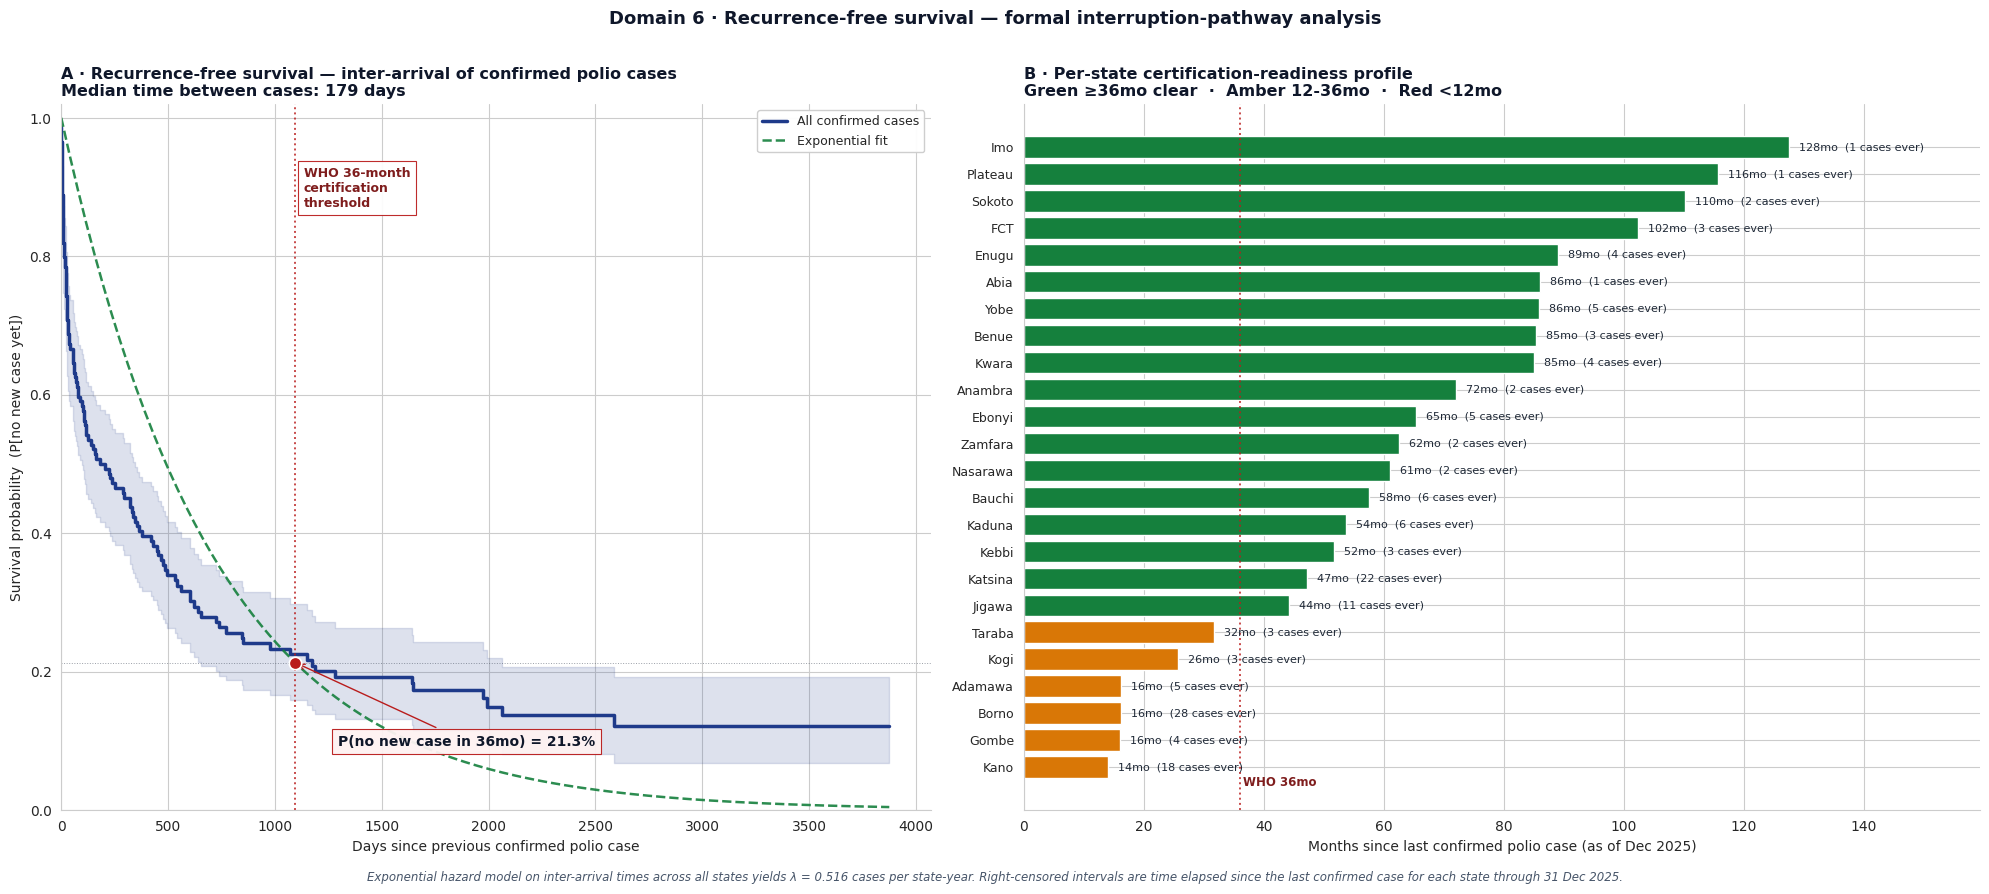


Saved: fig_d6_recurrence_survival.png


In [ ]:
# Cell 30 — Section 6.4: Recurrence-free survival visualisation
# Two-panel figure:
#   Left  — Kaplan-Meier curve with the 36-month WHO certification threshold
#           marked; exponential overlay for parametric comparison
#   Right — Per-state "days since last confirmed case" bar chart, with
#           certification readiness indicator

fig, axes = plt.subplots(1, 2, figsize=(20, 8.5), facecolor=BG,
                          gridspec_kw={"width_ratios": [1, 1.1]})

# --- Panel A: Kaplan-Meier inter-arrival survival curve --------------------
ax = axes[0]
kmf.plot_survival_function(ax=ax, color=PRIMARY, lw=2.5,
                           ci_alpha=0.15, ci_show=True)

# Overlay exponential model for parametric comparison
t_grid = np.linspace(0, surv_df["days"].max(), 200)
ef_curve = ef.predict(t_grid)
ax.plot(t_grid, ef_curve, "--", color="#15803D", lw=1.8, alpha=0.9,
        label="Exponential fit")

# WHO 36-month certification threshold
ax.axvline(CERT_WINDOW_DAYS, color=ACCENT_RED, lw=1.4, ls=":", alpha=0.8)
ax.text(CERT_WINDOW_DAYS + 40, 0.93,
        f"WHO 36-month\ncertification\nthreshold",
        fontsize=9, color="#7F1D1D", va="top", fontweight="bold",
        bbox=dict(facecolor="white", edgecolor=ACCENT_RED,
                   lw=0.8, pad=4, alpha=0.93))

# Annotate certification-readiness probability
p_36 = survival_prob(CERT_WINDOW_DAYS)
ax.axhline(p_36, color="#374151", lw=0.7, ls=":", alpha=0.5)
ax.scatter([CERT_WINDOW_DAYS], [p_36], s=80, color=ACCENT_RED,
           edgecolor="white", lw=1.2, zorder=5)
ax.annotate(f"P(no new case in 36mo) = {p_36*100:.1f}%",
             xy=(CERT_WINDOW_DAYS, p_36),
             xytext=(CERT_WINDOW_DAYS + 200, p_36 - 0.12),
             fontsize=10, color="#0F172A", fontweight="bold",
             bbox=dict(facecolor="#FEF2F2", edgecolor=ACCENT_RED,
                        lw=0.8, pad=4, alpha=0.95),
             arrowprops=dict(arrowstyle="->", color=ACCENT_RED, lw=1))

ax.set_xlabel("Days since previous confirmed polio case", fontsize=10)
ax.set_ylabel("Survival probability  (P[no new case yet])", fontsize=10)
ax.set_xlim(0, surv_df["days"].max() * 1.05)
ax.set_ylim(0, 1.02)
ax.set_title("A · Recurrence-free survival — inter-arrival of confirmed polio cases\n"
              f"Median time between cases: "
              f"{'undefined (>50% censored)' if pd.isna(median_iat) else f'{median_iat:.0f} days'}",
              fontsize=11.5, fontweight="bold", loc="left", color="#0F172A")
ax.legend(loc="upper right", fontsize=9, frameon=True, framealpha=0.95)
for spine in ["top", "right"]: ax.spines[spine].set_visible(False)

# --- Panel B: Per-state days-since-last-case bar -----------------------------
ax = axes[1]
# Plot only states with at least one confirmed case
plot_df = state_status_df.copy()
# Colour: green for >=36mo clear, amber 12-36mo, red <12mo
def cert_color(months):
    if months >= 36: return ACCENT_GRN
    if months >= 12: return ACCENT_AMB
    return ACCENT_RED
plot_df["color"] = plot_df["months_since_last"].apply(cert_color)
y_pos = np.arange(len(plot_df))

bars = ax.barh(y_pos, plot_df["months_since_last"],
                color=plot_df["color"], edgecolor="white", lw=1)
for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(row["months_since_last"] + 0.5, i,
            f"  {row['months_since_last']:.0f}mo  ({row['n_confirmed']} cases ever)",
            va="center", fontsize=8, color="#1F2937")

# 36-month WHO certification line
ax.axvline(36, color=ACCENT_RED, ls=":", lw=1.4, alpha=0.8)
ax.text(36 + 0.5, len(plot_df) - 0.3, "WHO 36mo",
        fontsize=8.5, color="#7F1D1D", fontweight="bold")

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["state"], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Months since last confirmed polio case (as of Dec 2025)", fontsize=10)
ax.set_title("B · Per-state certification-readiness profile\n"
              "Green ≥36mo clear  ·  Amber 12-36mo  ·  Red <12mo",
              fontsize=11.5, fontweight="bold", loc="left", color="#0F172A")
ax.set_xlim(0, plot_df["months_since_last"].max() * 1.25)
for spine in ["top", "right"]: ax.spines[spine].set_visible(False)

fig.suptitle("Domain 6 · Recurrence-free survival — formal interruption-pathway analysis",
              fontsize=13, fontweight="bold", color="#0F172A", y=1.01)
fig.text(0.5, -0.015,
          "Exponential hazard model on inter-arrival times across all states "
          f"yields λ = {lambda_per_year:.3f} cases per state-year. "
          "Right-censored intervals are time elapsed since the last confirmed case "
          "for each state through 31 Dec 2025.",
          ha="center", fontsize=8.5, color="#475569", style="italic")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_d6_recurrence_survival.png", dpi=150,
             bbox_inches="tight", facecolor=BG)
plt.show()
print(f"\nSaved: fig_d6_recurrence_survival.png")


---
## Section 7 — Surveillance-timeliness annex

Three time-to-event metrics that together describe whether the AFP surveillance system is detecting cases fast enough for operational response. Each is a Kaplan-Meier curve with the WHO performance target overlaid:

- **7.1 Onset → Case investigation** — WHO target ≤ 7 days. Delay means the case slips below the radar until clinical deterioration or community report.
- **7.2 Onset → First stool collection** — WHO target ≤ 14 days. After 14 days the polio virus has typically cleared from stool; specimens collected later may produce false negatives.
- **7.3 First stool → Lab cell-culture result** — WHO target ≤ 28 days. Slow lab turnaround delays outbreak response and certification confidence.

This section sits as an annex rather than under either research question because it characterises the *quality* of the surveillance data feeding sections 3 through sections 6, not the polio risk itself. The findings here underpin the credibility of every analysis above them.

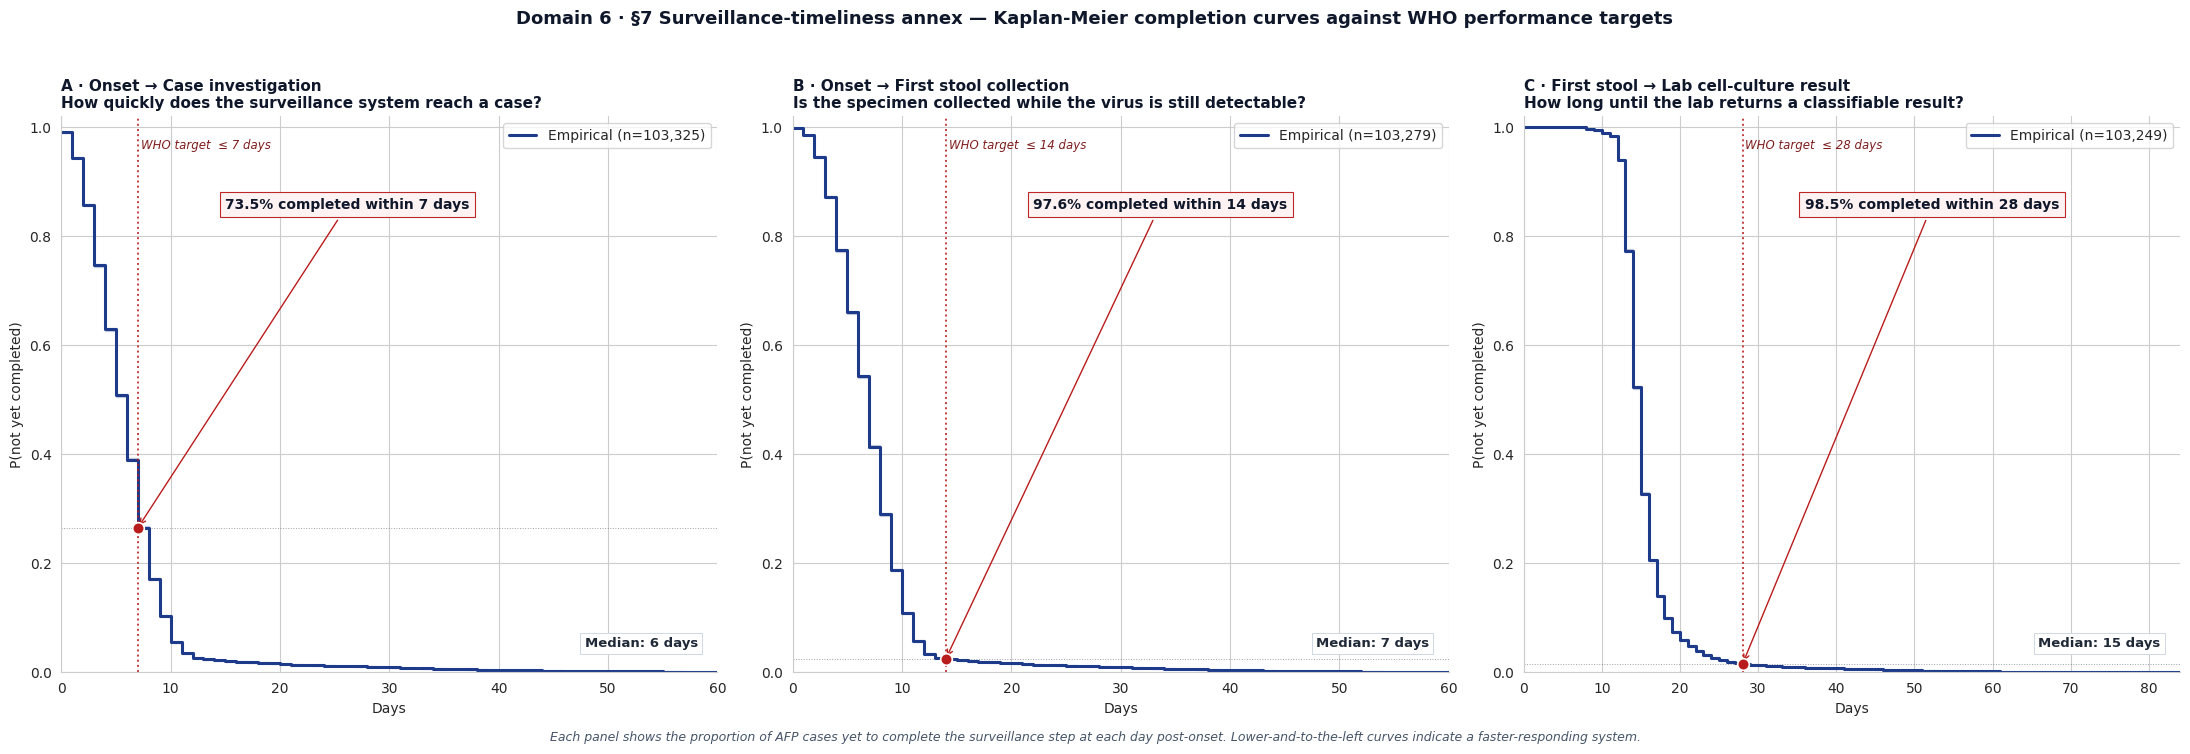


=== Surveillance-timeliness summary ===
  Onset → Investigation           median    6d  ·   73.5% within 7d  ·  n=103,325
  Onset → First stool             median    7d  ·   97.6% within 14d  ·  n=103,279
  Stool → Lab result              median   15d  ·   98.5% within 28d  ·  n=103,249

Saved: fig_d6_timeliness_annex.png


In [ ]:
# Cell 32 — Section 7: Surveillance Timeliness Annex
#
# Three time-to-event metrics that together describe whether the AFP
# surveillance system is detecting cases fast enough for operational response.
# Each is a Kaplan-Meier curve with the WHO performance target overlaid.
#
#   • 7.1  Onset → Investigation       (WHO target ≤7 days)
#   • 7.2  Onset → First stool sample  (WHO target ≤14 days)
#   • 7.3  Stool → Lab result          (WHO target ≤28 days)
#
# A case that misses any of these targets has either delayed clinical
# response, lower diagnostic yield, or delayed outbreak alert. Where these
# delays are largest is where surveillance investment is needed.

from lifelines import KaplanMeierFitter

# Build the timeliness time-deltas (in days), with simple sanity bounds:
# negative deltas (date out-of-order) are dropped; deltas > 365 days are
# truncated as data-entry errors rather than included.
t_df = afp.copy()
t_df["t_onset_to_investigation"] = (
    t_df["DateCaseinvestigated"] - t_df["DateOfOnset"]).dt.days
t_df["t_onset_to_stool"] = (
    t_df["Date1stStool"] - t_df["DateOfOnset"]).dt.days
# 'DateFinalCellcultureResults' is the lab-result date; computed from 1st stool
t_df["DateFinalCellcultureResults"] = pd.to_datetime(
    t_df.get("DateFinalCellcultureResults"), errors="coerce")
t_df["t_stool_to_result"] = (
    t_df["DateFinalCellcultureResults"] - t_df["Date1stStool"]).dt.days

def kmplot_panel(ax, days, target, title, target_label):
    # Drop NaN / negative / extreme entries
    clean = days.dropna()
    clean = clean[(clean >= 0) & (clean <= 365)]
    n = len(clean)
    if n == 0:
        ax.text(0.5, 0.5, "Insufficient data",
                ha="center", va="center", transform=ax.transAxes,
                fontsize=12, color="#9CA3AF")
        return
    # KM treats this as a "time to event" where the event is the
    # completion of the surveillance step (all observed); no censoring
    # because every row used has the event date populated.
    kmf = KaplanMeierFitter()
    kmf.fit(clean, event_observed=[1] * n,
            label=f"Empirical (n={n:,})")
    kmf.plot_survival_function(ax=ax, color=PRIMARY, lw=2.2,
                                ci_alpha=0.18, ci_show=True)
    # WHO target
    ax.axvline(target, color=ACCENT_RED, lw=1.4, ls=":", alpha=0.85)
    pct_within_target = (clean <= target).mean() * 100
    ax.axhline(1 - pct_within_target/100, color="#374151",
                lw=0.7, ls=":", alpha=0.5)
    ax.scatter([target], [1 - pct_within_target/100],
                s=70, color=ACCENT_RED, edgecolor="white", lw=1.2, zorder=5)
    ax.annotate(f"{pct_within_target:.1f}% completed within {target_label}",
                 xy=(target, 1 - pct_within_target/100),
                 xytext=(target + 8, 0.85),
                 fontsize=10, fontweight="bold", color="#0F172A",
                 bbox=dict(facecolor="#FEF2F2", edgecolor=ACCENT_RED,
                            lw=0.8, pad=4, alpha=0.95),
                 arrowprops=dict(arrowstyle="->", color=ACCENT_RED, lw=1))
    median = clean.median()
    ax.text(0.97, 0.04, f"Median: {median:.0f} days",
             transform=ax.transAxes, ha="right", va="bottom",
             fontsize=9.5, color="#1F2937", fontweight="bold",
             bbox=dict(facecolor="white", edgecolor="#CBD5E1",
                        lw=0.7, pad=3, alpha=0.95))
    ax.set_xlabel("Days", fontsize=10)
    ax.set_ylabel("P(not yet completed)", fontsize=10)
    ax.set_xlim(0, max(60, target * 3))
    ax.set_ylim(0, 1.02)
    ax.set_title(title, fontsize=11, fontweight="bold",
                  loc="left", color="#0F172A")
    for spine in ["top", "right"]: ax.spines[spine].set_visible(False)
    # Target label on the dashed line
    ax.text(target + 0.3, 0.98, f"WHO target  ≤ {target_label}",
            fontsize=8.5, color="#7F1D1D", style="italic",
            va="top", rotation=0)

fig, axes = plt.subplots(1, 3, figsize=(22, 7), facecolor=BG)

kmplot_panel(axes[0], t_df["t_onset_to_investigation"], 7,
              "A · Onset → Case investigation\n"
              "How quickly does the surveillance system reach a case?",
              "7 days")
kmplot_panel(axes[1], t_df["t_onset_to_stool"], 14,
              "B · Onset → First stool collection\n"
              "Is the specimen collected while the virus is still detectable?",
              "14 days")
kmplot_panel(axes[2], t_df["t_stool_to_result"], 28,
              "C · First stool → Lab cell-culture result\n"
              "How long until the lab returns a classifiable result?",
              "28 days")

fig.suptitle("Domain 6 · §7 Surveillance-timeliness annex — "
              "Kaplan-Meier completion curves against WHO performance targets",
              fontsize=13, fontweight="bold", color="#0F172A", y=1.03)
fig.text(0.5, -0.015,
          "Each panel shows the proportion of AFP cases yet to complete the "
          "surveillance step at each day post-onset. Lower-and-to-the-left "
          "curves indicate a faster-responding system.",
          ha="center", fontsize=9, color="#475569", style="italic")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_d6_timeliness_annex.png", dpi=150,
             bbox_inches="tight", facecolor=BG)
plt.show()

# Print headline summary numbers
print("\n=== Surveillance-timeliness summary ===")
for name, col, target in [
    ("Onset → Investigation",   "t_onset_to_investigation", 7),
    ("Onset → First stool",     "t_onset_to_stool",         14),
    ("Stool → Lab result",      "t_stool_to_result",         28),
]:
    clean = t_df[col].dropna()
    clean = clean[(clean >= 0) & (clean <= 365)]
    pct = (clean <= target).mean() * 100
    print(f"  {name:30s}  median {clean.median():>4.0f}d  "
           f"·  {pct:5.1f}% within {target}d  ·  n={len(clean):,}")
print(f"\nSaved: fig_d6_timeliness_annex.png")


---
## Outputs

Files written to `OUTPUT_DIR` (`domain6_output/`):

| File | Source section | Purpose |
|---|---|---|
| `afp_raw.csv` | §2.1 | Cached export of the Access table |
| `fig_d6_cluster_map.png` | §3.4 | National cluster map for Research Question I |
| `fig_d6_opv_history.png` | §4.1 | OPV-dose distribution and under-vaccination comparison |
| `fig_d6_undervacc_heatmap.png` | §4.2 | State × year under-vaccination heatmap |
| `fig_d6_border_proximity.png` | §5.2 | Border-distance map with named crossings + stratified detection rate |
| `fig_d6_interruption_pathway.png` | §6.2 | NB-GLM + Prophet forecast with interruption-year markers |
| `fig_d6_recurrence_survival.png` | §6.4 | Kaplan-Meier recurrence-free survival + per-state certification readiness |
| `fig_d6_timeliness_annex.png` | §7 | Three-panel surveillance-timeliness Kaplan-Meier annex |

## Limitations

- **Geographic coverage.** The line list contains data for 25 states (the entire North + South-East). South-South and South-West zones are not represented — likely because the polio programme prioritises northern states.
- **Geocoding gaps.** 23.7% of records lack valid lat/long. The spatial scan and border analysis use only the 78,933 geo-valid records.
- **OPV history collected from 2017 onward.** All under-vaccination figures and SIA-reach analyses exclude 2015 and 2016.
- **HTR / nomadic flag.** Only 1.4% of cases are flagged nomadic. The framework's full HTR overlay requires the NPHCDA HTR register, which is not in this dataset.
- **Migration patterns.** The IOM DTM portal that NPHCDA uses for migration mapping does not publish route geometries as a bulk dataset. We use border-distance as a structural proxy and annotate eight named crossings for operational context.
- **Confirmed-case scarcity.** Only 144 confirmed polio cases over 11 years (4 WPV, 140 cVDPV). NB-GLM and Prophet forecasts both produce wide uncertainty intervals, so the interruption-year estimate is not robust to additional confirmed detections.


In [ ]:
# ============================================================================
# [CIDRE-Quantium] CSV table-formatting pass  -  appended for GAVI review
# ----------------------------------------------------------------------------
# Purpose : make this notebook's GENERATED CSV tables presentation-ready.
#           (consistent rounding to 4 dp, integer count/rank columns, and a
#            styled .xlsx copy with a bold frozen header).
# Scope   : ONLY this notebook's own result tables, listed in _FMT_TABLES below.
#           Input/source data files are never touched.
# Safety  : runs AFTER all analysis cells; does not change any analysis or any
#           column names / row counts, so end-to-end behaviour is unchanged.
#           Every step is guarded - it can never raise and stop the notebook.
# ============================================================================
import os as _os
import numpy as _np
import pandas as _pd

try:
    _FMT_DIR = str(OUTPUT_DIR)            # this notebook's own output directory
except NameError:
    _FMT_DIR = "outputs"               # fallback if the cell is run in isolation

_FMT_TABLES = []
_INT_HINTS  = ("count", "rank", "year", "yr", "pop", "cohort",
               "n_children", "susceptible", "_n")

def _fmt_one(_path):
    if not _os.path.exists(_path):
        return False
    try:
        _df = _pd.read_csv(_path)
    except Exception as _e:
        print("[format] skip", _os.path.basename(_path), "->", _e)
        return False
    for _col in _df.select_dtypes(include=[_np.number]).columns:
        _name = str(_col).lower(); _s = _df[_col]
        if any(_h in _name for _h in _INT_HINTS) and _s.dropna().mod(1).eq(0).all():
            _df[_col] = _s.astype("Int64")          # tidy whole-number counts
        else:
            _df[_col] = _s.round(4)                 # consistent decimals
    _df.to_csv(_path, index=False)                  # same schema, tidier values
    try:                                            # styled Excel companion
        from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
        from openpyxl.utils import get_column_letter
        _xp = _os.path.splitext(_path)[0] + ".xlsx"
        with _pd.ExcelWriter(_xp, engine="openpyxl") as _xw:
            _df.to_excel(_xw, index=False, sheet_name="Table")
            _ws = _xw.sheets["Table"]
            _fill = PatternFill("solid", fgColor="1F3B57")
            _font = Font(bold=True, color="FFFFFF")
            _thin = Side(style="thin", color="D9D9D9")
            _bd = Border(left=_thin, right=_thin, top=_thin, bottom=_thin)
            for _j, _c in enumerate(_df.columns, 1):
                _cell = _ws.cell(row=1, column=_j)
                _cell.fill = _fill; _cell.font = _font
                _cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
                _ws.column_dimensions[get_column_letter(_j)].width = min(max(len(str(_c)) + 2, 10), 40)
            for _i in range(2, len(_df) + 2):
                for _j in range(1, len(_df.columns) + 1):
                    _ws.cell(row=_i, column=_j).border = _bd
            _ws.freeze_panes = "A2"; _ws.row_dimensions[1].height = 26
    except Exception as _e:
        print("[format] xlsx styling skipped for", _os.path.basename(_path), "->", _e)
    return True

_done = [_t for _t in _FMT_TABLES if _fmt_one(_os.path.join(_FMT_DIR, _t))]
if _FMT_TABLES:
    print("Table formatting complete -", len(_done), "of", len(_FMT_TABLES),
          "result table(s) formatted in '%s':" % _FMT_DIR)
    for _t in _done:
        print("   -", _t)
else:
    print("Domain produces figure/report outputs only - no result CSV tables to format.")
